# Deep Learning-based Anomaly Detection

Industrial quality inspection has a hard problem at its core: the set of things that can go wrong on a production line is never fully known in advance. A new scratch pattern, stain, lighting artifact, or surface texture can show up on the line that nobody has photographed before. This material covers why that matters, and how to build a system that can flag "this does not look right" without first being shown every possible way something can be wrong.

The idea rests on two building blocks:
- **Feature embeddings**: a pretrained deep learning model can turn an image into a vector of numbers that describes what the image looks like, without us ever training it on our steel images. Visually similar images end up with similar vectors.
- **PatchCore**: a practical algorithm that stores the feature vectors of many normal images as a memory of what normal looks like, then flags a new image as anomalous when its local features are far from anything in that memory.

<div class='alert alert-info'>

:::{note}
**Running theme**: a single quality inspector working the same steel line. She has seen enough normal steel over the years that something unfamiliar catches her eye immediately, even a defect type she couldn't name. Section 1 shows what happens when she is instead only allowed to recognize defect types she has personally been shown a labeled photo of. The rest of the notebook is about building a system that can do the same thing she does, without needing to be shown every possible defect type in advance.
:::
</div>

<div class='alert alert-info'>

:::{objectives}
- Supervised classification, and why it struggles when the set of possible defects is open-ended
- Feature embeddings: how a pretrained neural network turns an image into vectors
- Anomaly detection with PatchCore: using those vectors to ask "have we seen something like this in normal production?" instead of "which class is this?"
:::
</div>

In [ ]:
import os
from pathlib import Path

MODULE_ROOT = Path.cwd()
DEFAULT_MODULE_ROOT = Path(r'C:\coding\MIMER\Training01_DL_in_MS\V1_D2_Anomaly_Detection')
if not (MODULE_ROOT / 'dataset').exists() and DEFAULT_MODULE_ROOT.exists():
    MODULE_ROOT = DEFAULT_MODULE_ROOT

DATASET_ROOT = MODULE_ROOT / 'dataset'
MODEL_CACHE = MODULE_ROOT / '_model_cache'
MODEL_CACHE.mkdir(exist_ok=True)

os.environ.setdefault('TORCH_HOME', str(MODEL_CACHE / 'torch'))
os.environ.setdefault('HF_HOME', str(MODEL_CACHE / 'huggingface'))
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')

print('Module root:', MODULE_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Model cache:', MODEL_CACHE)


In [2]:
from IPython.display import Image, display
import numpy as np
import torch
import matplotlib.pyplot as plt

## 1. What Problem Are We Solving?

Typically in vision tasks, we have a closed set of classes and a closed set of labels. For example:

- a classifier learns from labeled classes;
- a detector learns from boxes;
- a segmenter learns from masks.

The problem is that in many real cases, the defect space is open ended: a new scratch pattern, stain, lighting artifact, inclusion, or surface texture can appear even if it was never present in the training labels. So the learning problem changes from **recognize this known class** to **learn normality well enough to flag what does not fit**.

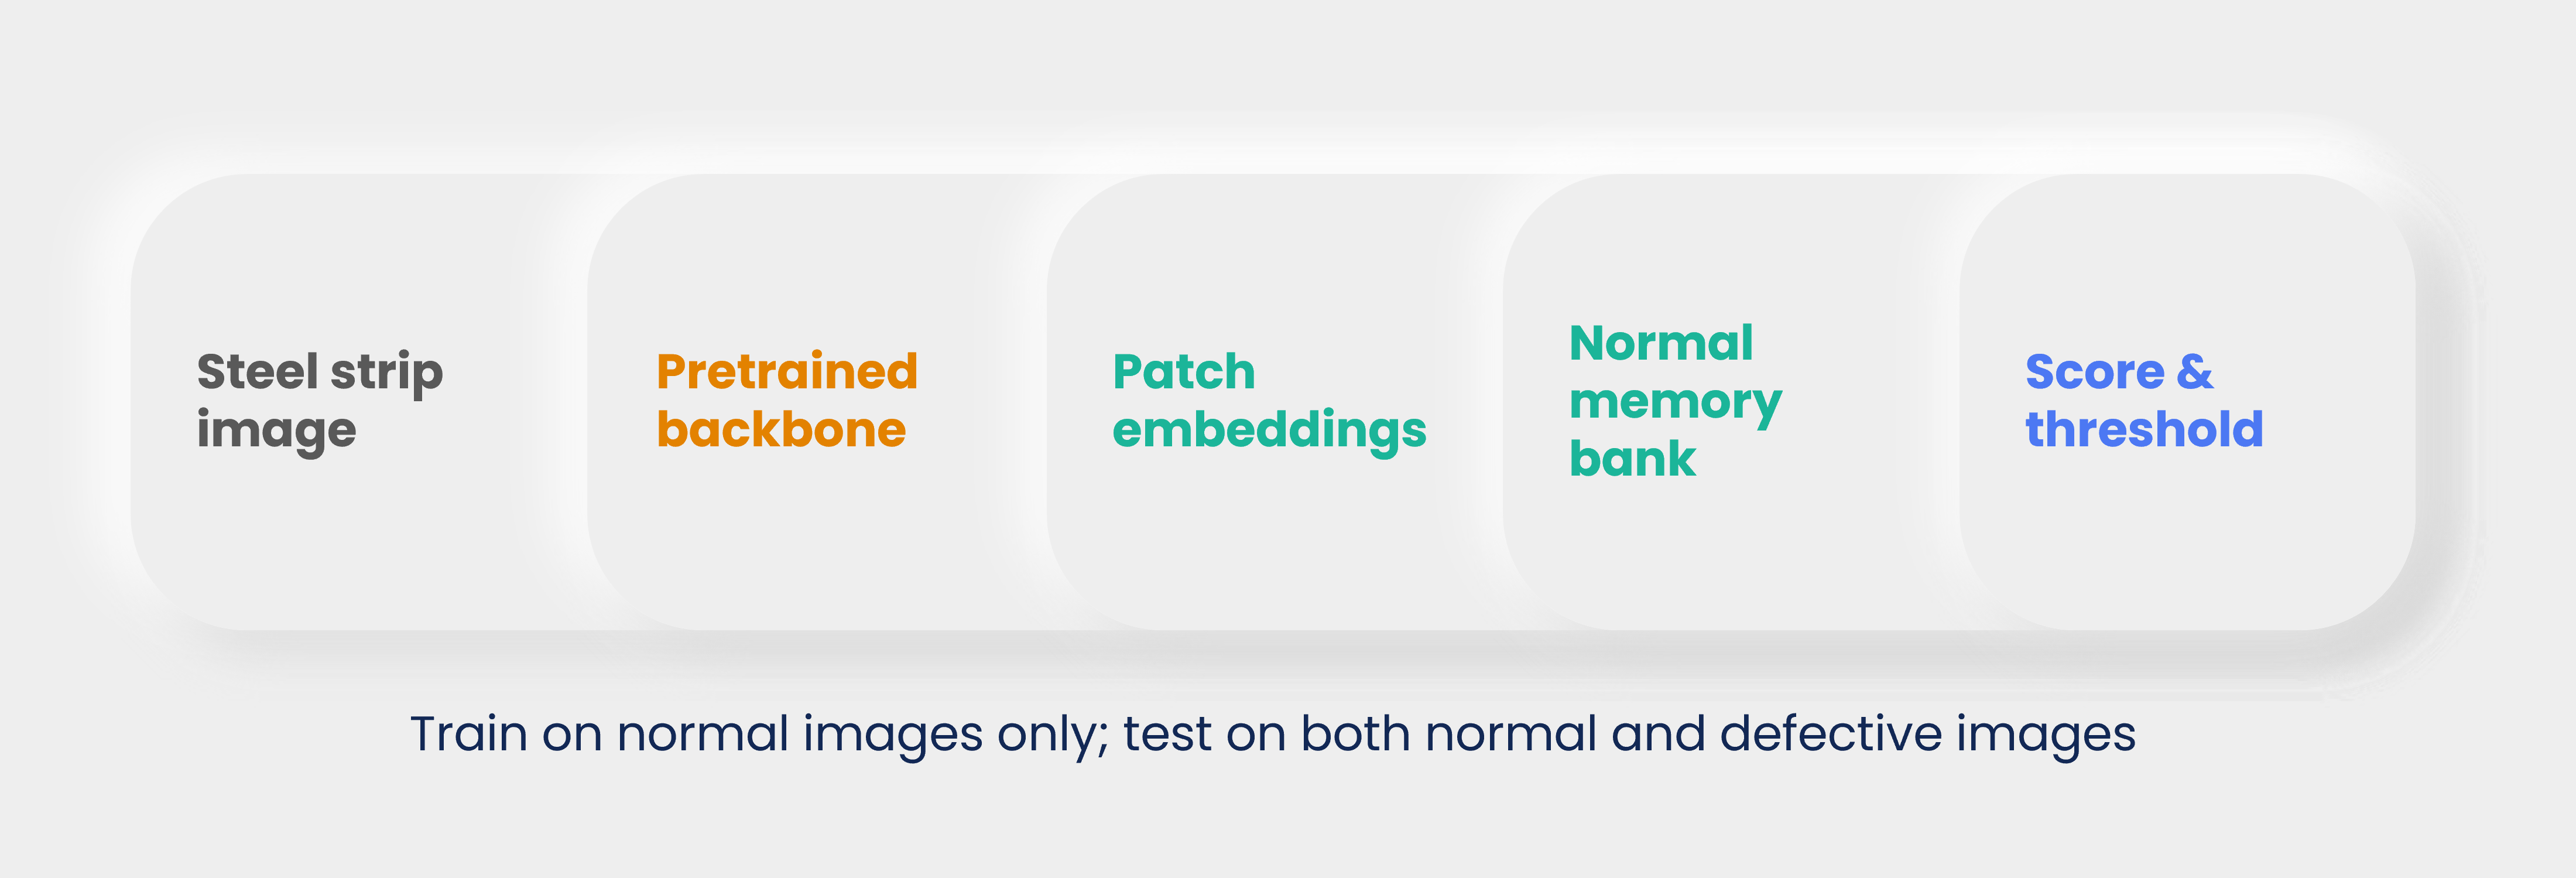

In [ ]:
display(Image('../episodes/Fig/01_Industrial_AD_Workflow.png', width=650))

*Figure 1: The anomaly detection workflow. During training, only normal images are used to build a representation of acceptable appearance. During testing, new images are compared against that normal representation.*

A concrete example is an experienced quality inspector working on a steel production line. She may not know the name of every possible defect, but after years on the line she has seen enough normal steel that something unfamiliar catches her eye immediately, even a defect type she couldn't name. Anomaly detection tries to formalize that instinct with feature vectors. Section 1.3 shows what happens if we instead only let her flag defects she has been explicitly shown a labeled photo of.

### 1.1 Normality is the Training Signal

A one-class setup trains on normal images only. That does not mean defects are useless. Defect images are still useful for validation, threshold selection, and evaluating whether the anomaly score is meaningful.

In this module:

- `dataset/anomaly/train/normal` contains normal images for PatchCore memory building;
- `dataset/anomaly/test/normal` contains held-out normal images;
- `dataset/anomaly/test/defect` contains defect images for evaluation.

The model never needs defect images to build the memory bank. This is the key distinction from ordinary binary classification.

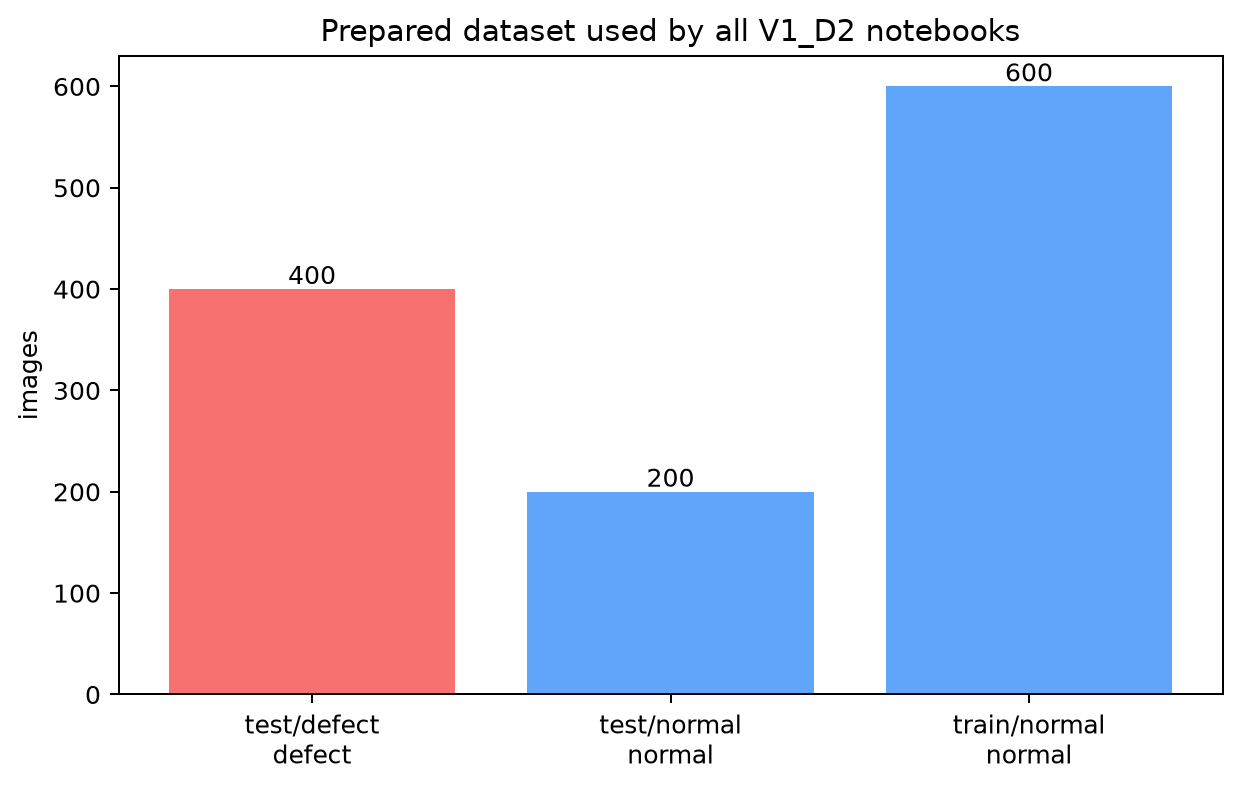

In [ ]:
display(Image('../episodes/Fig/01_Prepared_Dataset_Splits.png', width=650))

*Figure 2: The prepared workshop split. The training set contains only normal images, while the test set contains both normal and defective images.*

This split is deliberately different from a supervised classifier split. A classifier would usually train with both "normal" and "defect" labels. The PatchCore anomaly detection method only stores what normal looks like, then asks whether test images fit that stored normal appearance.


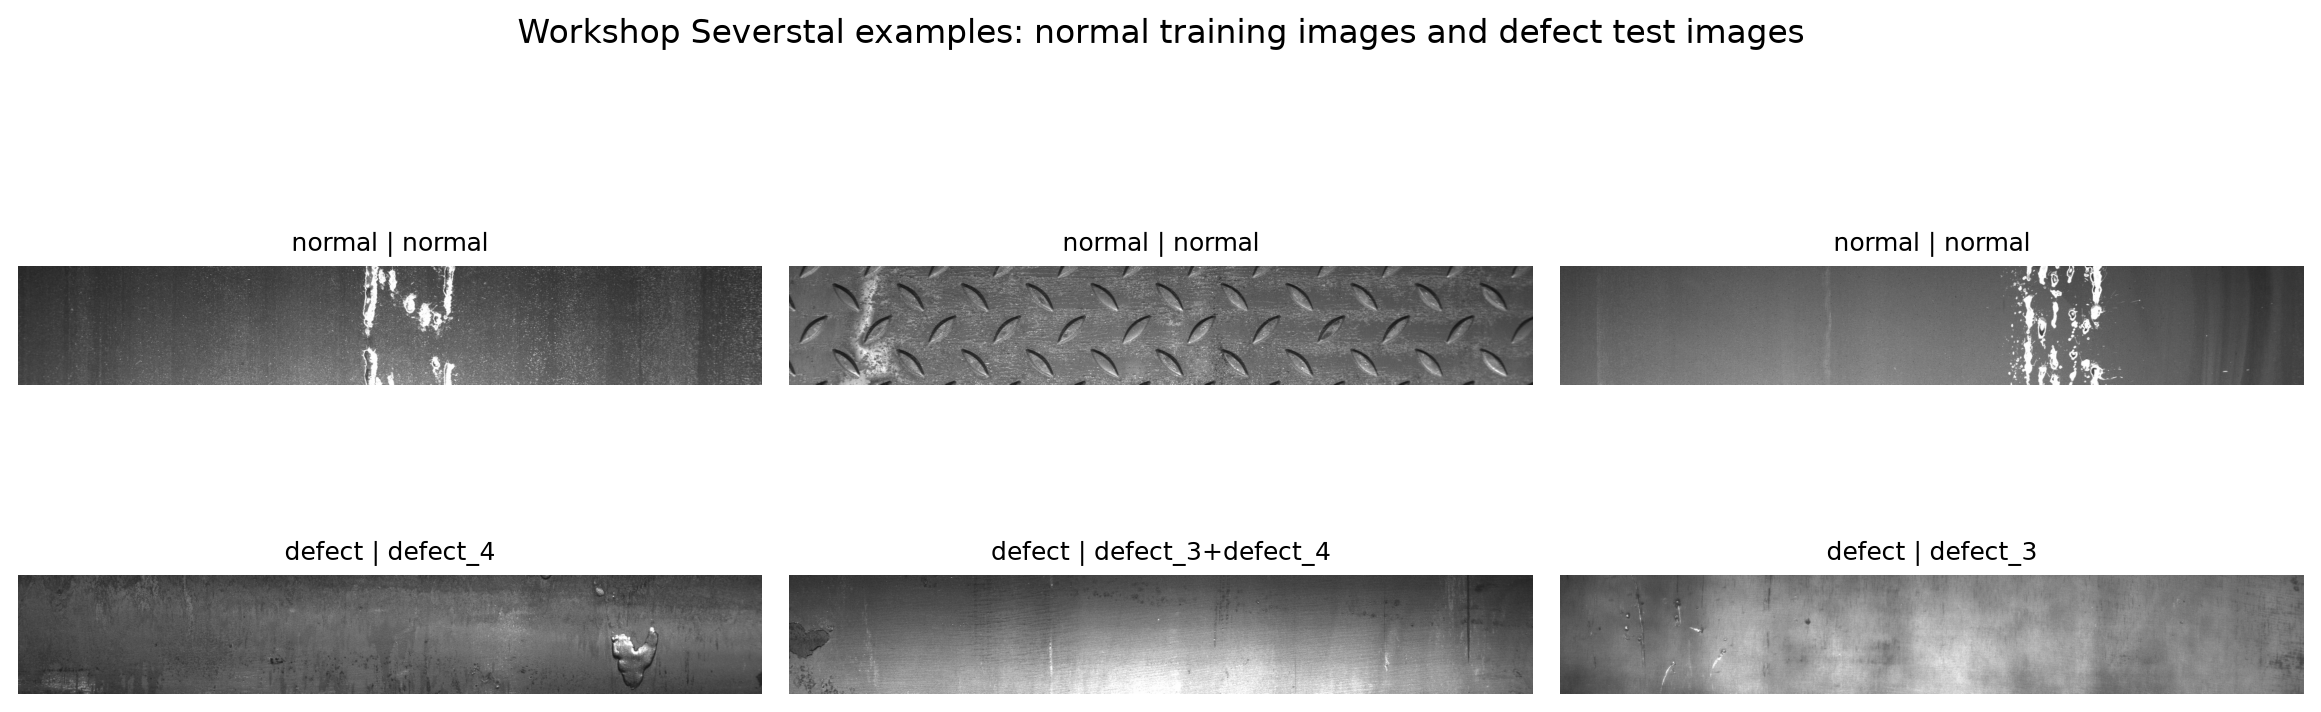

In [3]:
display(Image('../episodes/Fig/01_Severstal_Workshop_Examples.png', width=950))

*Figure 3: Example steel strips from the prepared workshop dataset. The normal images define the reference behavior. The defect images are used to evaluate whether the model can flag abnormal appearance.*

<div class='alert alert-info'>

:::{note}
Notice that the whole image is mostly steel even when a defect exists. This matters because a single image-level vector can wash out a small local defect. PatchCore therefore works with local patch features, but we are getting ahead of ourselves. First, the obvious idea.
:::
</div>

### 1.2 A Simple Tirst Model: the MLP

Before reaching for a pretrained backbone, it is worth asking: what is the simplest possible model we could train directly on these images? The classic starting point (see e.g. [bentrevett/pytorch-image-classification](https://github.com/bentrevett/pytorch-image-classification)) is a **multi-layer perceptron (MLP)**: flatten the image into one long list of pixel values and feed it through a few fully-connected layers.

An MLP has no notion of "nearby pixels belong together" -- it treats pixel 1 and pixel 10,000 exactly the same way, as two unrelated numbers in a long list. That makes it a reasonable first thing to try and a useful reference point, but a weak choice for real images: it cannot exploit the fact that a scratch is a local pattern of neighboring pixels, and flattening even a fairly low resolution color image already produces a very long input vector before the network does anything useful with it.

The cell below trains a tiny MLP directly on flattened, downsized workshop images, purely to make this concrete. Do not read too much into its accuracy, the point is the architecture, not the number.

In [6]:
import pandas as pd
from PIL import Image as PILImage
import torchvision.transforms as T

mlp_metadata = pd.read_csv(DATASET_ROOT / 'metadata.csv')
mlp_normal = mlp_metadata[mlp_metadata['label'] == 'normal'].sample(60, random_state=0)
mlp_defect = mlp_metadata[mlp_metadata['label'] == 'defect'].sample(60, random_state=1)

MLP_IMAGE_SIZE = 32  # deliberately tiny -- an MLP has no way to exploit spatial structure anyway
mlp_transform = T.Compose([T.Resize((MLP_IMAGE_SIZE, MLP_IMAGE_SIZE)), T.Grayscale(), T.ToTensor()])

def load_flat(frame):
    tensors = [mlp_transform(PILImage.open(DATASET_ROOT / row['relative_path']).convert('RGB')) for _, row in frame.iterrows()]
    return torch.stack(tensors).reshape(len(frame), -1)

X_mlp = torch.cat([load_flat(mlp_normal), load_flat(mlp_defect)])
y_mlp = torch.cat([torch.zeros(len(mlp_normal)), torch.ones(len(mlp_defect))])

mlp = torch.nn.Sequential(
    torch.nn.Linear(MLP_IMAGE_SIZE * MLP_IMAGE_SIZE, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1),
)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = torch.nn.BCEWithLogitsLoss()

for epoch in range(60):
    optimizer.zero_grad()
    logits = mlp(X_mlp).squeeze(1)
    loss = loss_fn(logits, y_mlp)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    mlp_accuracy = ((mlp(X_mlp).squeeze(1) > 0) == y_mlp.bool()).float().mean()
print(f'Tiny MLP training accuracy on {len(X_mlp)} flattened {MLP_IMAGE_SIZE}x{MLP_IMAGE_SIZE} grayscale images: {mlp_accuracy:.1%}')

Tiny MLP training accuracy on 120 flattened 32x32 grayscale images: 84.2%


Treating every pixel as an independent input, with no notion of neighboring structure, is exactly the MLP's limitation. In practice, for real images, we do not train a network from raw pixels at all: we reuse a large **pretrained** deep learning model as a fixed feature extractor, and only train a small classifier on top of the vectors it produces. The next section builds exactly that, and shows where even that more realistic setup runs into trouble.

### 1.3 A More Realistic Classifier: Pretrained Backbone + Head

Every experienced ML engineer's first instinct here is reasonable: we have labeled images (`defect_1`, `defect_2`, `defect_3`, `defect_4`, and combinations), so why not train an ordinary supervised classifier (normal vs. defect, or even normal vs. each defect type) and skip anomaly detection entirely?

Rather than argue about this in the abstract, let's actually do it, on the real prepared dataset, and see exactly where it breaks.

First, some vocabulary that shows up throughout this notebook: most modern image models split into a **backbone** and a **head**. The backbone is the large pretrained part that turns an image into a feature vector (Section 2 covers this in detail); the head is a small, task-specific piece bolted on top of that vector to produce the actual prediction. Swapping the head lets you reuse the same expensive, pretrained backbone for different tasks.

We will:
1. Deliberately **hold out one entire real defect type** (`defect_4`, 46 images) from training entirely, as a stand-in for "a defect that shows up on the line next year that nobody has photographed yet."
2. Pass images through a frozen, pretrained deep learning model to get a feature vector for each one (the backbone), then train a **logistic regression** classifier on top of those vectors (the head) on normal images plus the *other* defect types.
3. Check accuracy on defect types the classifier *did* see in training.
4. Then check what happens when we show it the held-out type it never saw.

Why logistic regression as the head, instead of a small neural network? It is a really simple classifier head, and we use it to make a point: once you have a good feature vector, *any* classifier -- a traditional ML method like logistic regression, or a small neural fully-connected (FC) layer -- can act as the head on top of it. The choice of head is fairly independent of the choice of backbone; later modules in this workshop series replace this logistic regression head with a neural-network head, while the underlying idea of "frozen backbone, trainable head" stays the same.

The point of the experiment below is not to get the best possible classifier, but to see what happens when we try to use a supervised approach in an open-ended defect space.

In [7]:
import pandas as pd
from PIL import Image as PILImage
import torchvision.transforms as T
import timm
from sklearn.linear_model import LogisticRegression

theory_metadata = pd.read_csv(DATASET_ROOT / 'metadata.csv')
HELD_OUT_CLASS = 'defect_4'  # pretend this defect type has never been photographed before

normals = theory_metadata[theory_metadata['label'] == 'normal']
seen_defects = theory_metadata[(theory_metadata['label'] == 'defect') & (theory_metadata['defect_class'] != HELD_OUT_CLASS)]
unseen_defects = theory_metadata[theory_metadata['defect_class'] == HELD_OUT_CLASS]

N_PER_GROUP = 90
normal_sample = normals.sample(n=min(2 * N_PER_GROUP, len(normals)), random_state=0)
defect_sample = seen_defects.sample(n=min(2 * N_PER_GROUP, len(seen_defects)), random_state=0)
unseen_sample = unseen_defects.sample(n=min(N_PER_GROUP, len(unseen_defects)), random_state=0)

train_normal, test_normal = normal_sample.iloc[:N_PER_GROUP], normal_sample.iloc[N_PER_GROUP:]
train_defect, test_defect = defect_sample.iloc[:N_PER_GROUP], defect_sample.iloc[N_PER_GROUP:]

classifier_backbone = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
classifier_backbone.eval()
classifier_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def embed_images(frame):
    # One image at a time, for readability -- the hands-on notebook batches this for speed.
    vectors = []
    with torch.no_grad():
        for _, row in frame.iterrows():
            image = PILImage.open(DATASET_ROOT / row['relative_path']).convert('RGB')
            vectors.append(classifier_backbone(classifier_transform(image).unsqueeze(0)).squeeze(0).numpy())
    return np.stack(vectors)

X_train = np.concatenate([embed_images(train_normal), embed_images(train_defect)])
y_train = np.concatenate([np.zeros(len(train_normal)), np.ones(len(train_defect))])
classifier = LogisticRegression(max_iter=2000).fit(X_train, y_train)

X_test_normal, X_test_defect = embed_images(test_normal), embed_images(test_defect)
X_test = np.concatenate([X_test_normal, X_test_defect])
y_test = np.concatenate([np.zeros(len(test_normal)), np.ones(len(test_defect))])
seen_accuracy = classifier.score(X_test, y_test)
seen_catch_rate = classifier.predict(X_test_defect).mean()

X_unseen = embed_images(unseen_sample)
unseen_catch_rate = classifier.predict(X_unseen).mean()

print(f'Overall accuracy on defect types SEEN during training: {seen_accuracy:.1%}')
print(f'Catch rate on SEEN defect types:                       {seen_catch_rate:.1%}')
print(f'Catch rate on "{HELD_OUT_CLASS}" (NEVER seen during training):    {unseen_catch_rate:.1%}')


C:\coding\MIMER\Training01_DL_in_MS\V1_D2_Anomaly_Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overall accuracy on defect types SEEN during training: 78.3%
Catch rate on SEEN defect types:                       87.8%
Catch rate on "defect_4" (NEVER seen during training):    56.5%


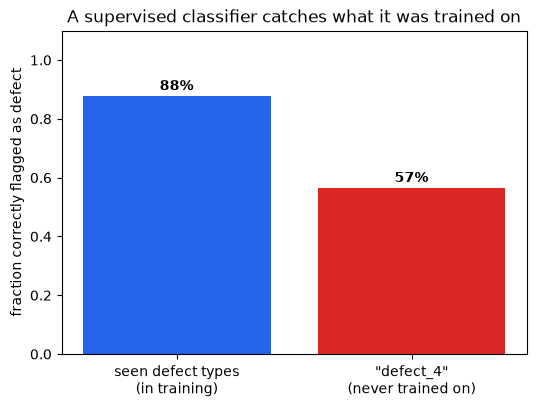

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(
    ['seen defect types\n(in training)', f'"{HELD_OUT_CLASS}"\n(never trained on)'],
    [seen_catch_rate, unseen_catch_rate],
    color=['#2563eb', '#dc2626'],
)
for bar, value in zip(bars, [seen_catch_rate, unseen_catch_rate]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.0%}', ha='center', fontweight='bold')
ax.set_ylabel('fraction correctly flagged as defect')
ax.set_ylim(0, 1.1)
ax.set_title('A supervised classifier catches what it was trained on')
plt.show()

This is a real, measured result on real steel images, not a hypothetical. Whatever the exact numbers were on your run, the pattern should be clear: the classifier is much better at catching defect types it trained on than the one type it never saw, even though, to a human inspector, `defect_4` is just as visibly "not normal steel" as the others.

This is not because logistic regression is a weak classifier, and it is not fixable by using a bigger neural network. It is a **structural** property of closed-set supervised learning: the model's decision boundary is shaped entirely by the classes it was shown, and a genuinely new pattern can land anywhere relative to that boundary, including confidently on the "normal" side.


Why this happens: a decision boundary only knows what it was shown!

The plot below makes the same failure concrete in a 2D toy feature space, where we can actually draw the boundary. Three known defect "clusters" and one normal cluster are used to fit a classifier; then a fourth cluster -- a defect type the classifier never saw -- is added afterward, without retraining. You don't need to read the plotting code; watch where the new (yellow) points fall relative to the shaded decision regions.


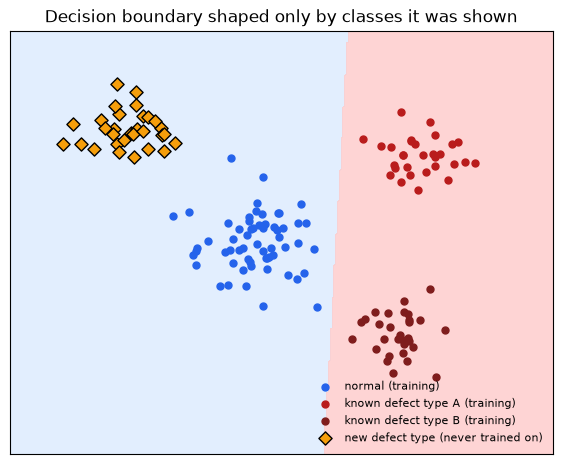

In [ ]:
from sklearn.linear_model import LogisticRegression as ToyClassifier

rng = np.random.default_rng(3)
normal_2d = rng.normal([0, 0], 0.6, size=(60, 2))
known_defect_a = rng.normal([3.2, 2.0], 0.5, size=(30, 2))
known_defect_b = rng.normal([3.0, -2.2], 0.5, size=(30, 2))
unseen_defect = rng.normal([-2.8, 2.6], 0.5, size=(30, 2))  # never shown to the classifier

X_toy = np.concatenate([normal_2d, known_defect_a, known_defect_b])
y_toy = np.concatenate([np.zeros(len(normal_2d)), np.ones(len(known_defect_a) + len(known_defect_b))])
toy_classifier = ToyClassifier().fit(X_toy, y_toy)

xx, yy = np.meshgrid(np.linspace(-5, 6, 300), np.linspace(-5, 5, 300))
grid_pred = toy_classifier.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(xx, yy, grid_pred, levels=[-0.5, 0.5, 1.5], colors=['#dbeafe', '#fecaca'], alpha=0.8)
ax.scatter(*normal_2d.T, s=25, color='#2563eb', label='normal (training)')
ax.scatter(*known_defect_a.T, s=25, color='#b91c1c', label='known defect type A (training)')
ax.scatter(*known_defect_b.T, s=25, color='#7f1d1d', label='known defect type B (training)')
ax.scatter(*unseen_defect.T, s=45, color='#f59e0b', marker='D', label='new defect type (never trained on)', edgecolor='black')
ax.set_title('Decision boundary shaped only by classes it was shown')
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.set_xticks([]); ax.set_yticks([])
plt.show()

*Caption: Blue-shaded region = "predicted normal", red-shaded region = "predicted defect". The classifier's boundary was fit using only the blue and red training points -- it has no way of knowing where a truly new defect type will fall, and here the new type lands mostly inside the "normal" region.*

This is exactly what an **open-set recognition** problem looks like: the model was trained under a closed-world assumption (every category it will ever see was present during training), but the real world keeps introducing categories it never "knew" about.


**It gets worse with class imbalance**.

The held-out-class experiment isolates one failure mode. A second, compounding problem is visible directly in this workshop's own data: real defect classes are not evenly represented.

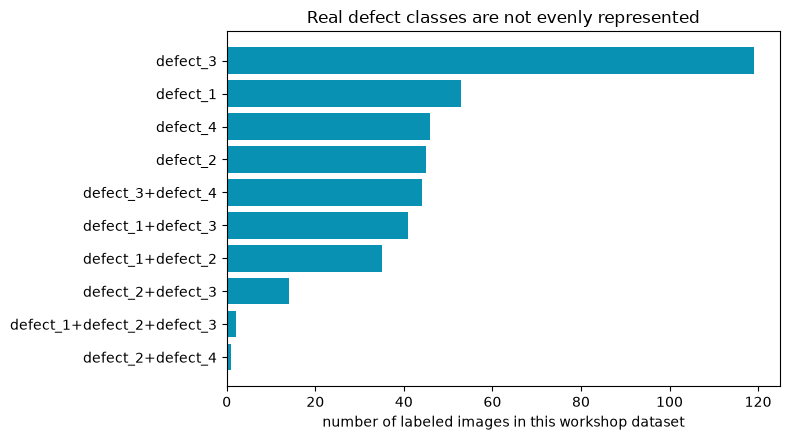

In [ ]:
class_counts = theory_metadata[theory_metadata['label'] == 'defect']['defect_class'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(class_counts.index[::-1], class_counts.values[::-1], color='#0891b2')
ax.set_xlabel('number of labeled images in this workshop dataset')
ax.set_title('Real defect classes are not evenly represented')
plt.tight_layout()
plt.show()

*Caption: Live counts from `dataset/metadata.csv`. A classifier trained on this distribution will, by default, get very little signal about the rarest combinations -- and combinations with only 1-2 examples cannot be meaningfully learned or evaluated at all.*

<div class='alert alert-warning'>

:::{callout}
Put the two problems together -- a closed-set boundary, fit on an imbalanced and incomplete label set -- and "just train a classifier" doesn't look like a shortcut anymore. It will require re-labeling and re-training every time production introduces a new defect pattern or the class balance drifts. 

This is the reason why many automated inspection initiatives fail in practice: the model is only as good as the labels it was trained on, and the labels are only as good as the human effort that produced them. Once something changes, the model is no longer valid, and nobody has the time or budget to collect and label a new dataset every time a new defect appears on the line.
:::
</div>

### 1.4 From Classifier to Anomaly Detector

None of this means supervised classifiers are bad -- they are usually the *right* choice when the category list is genuinely closed and stable (this is what the V1_D4 transfer-learning module covers). Anomaly detection shines when that assumption breaks down, which is common in inspection settings.

| | Supervised binary classifier | One-class anomaly detector (PatchCore) |
|---|---|---|
| Needs labeled defect examples? | Yes, for every category it should catch | No, trains on normal images only |
| New, never-seen defect type appears | Likely missed | Can be caught, if it looks unlike normal |
| Rare / imbalanced defect classes | Hurts training directly | Irrelevant, defects are never a training class |
| Output | A label (and maybe a probability) | A continuous "how far from normal" score |
| When production changes | Usually needs re-labeling + re-training | Memory bank can be rebuilt from new normal images only, no re-labeling needed. |
| Best suited for | A stable, fully-enumerated set of known categories | Open-ended, evolving, or rare-defect inspection settings |

The rest of this notebook builds the one-class alternative from the ground up: same idea of turning images into feature vectors, but the question asked of those vectors changes from *"which learned category is this closest to?"* to *"have we seen anything like this in normal production?"*

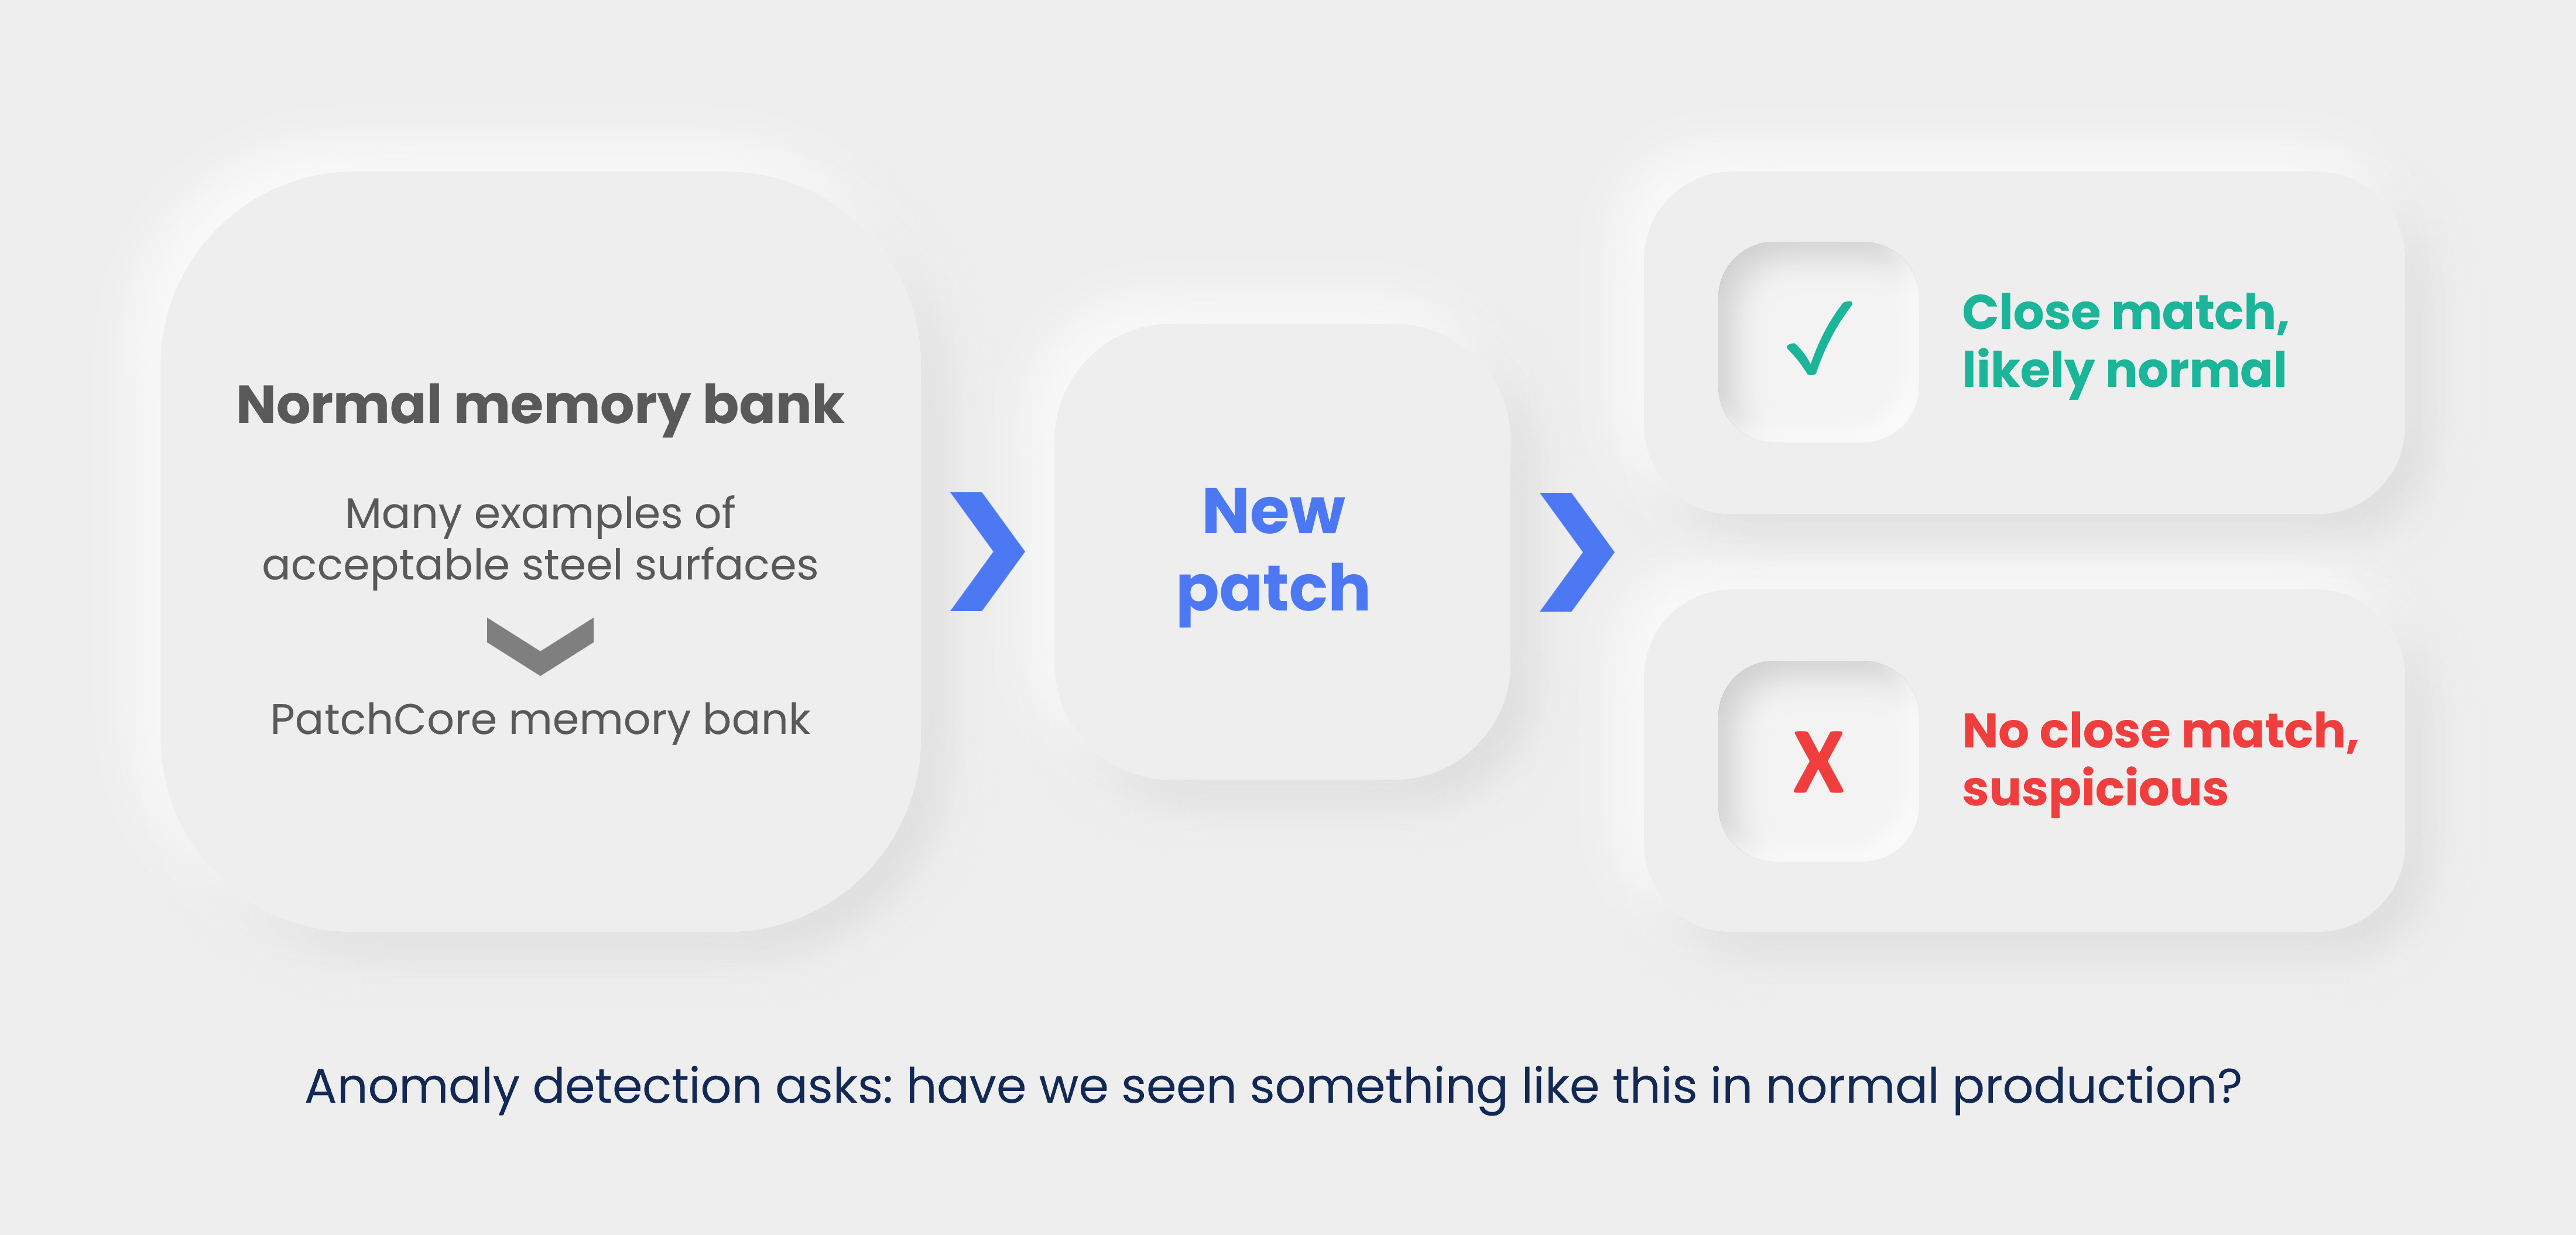

In [4]:
display(Image('../episodes/Fig/01_Normal_Catalog_Intuition.png', width=850))


*Figure 4: One-class anomaly detection as a normal catalog. The central question is not "which defect class is this?" but "does this new local pattern have a close match among normal patterns?"*

This is why anomaly detection can handle unknown defect types better than a closed-set classifier: it does not need a class name for a new defect. It only needs the new region to be sufficiently unlike normal regions -- exactly the property the yellow diamonds in Figure 3b were missing.


## 2. From Images to Patch Embeddings

A pretrained backbone converts pixels into feature vectors.

For anomaly detection, the classifier head introduced in Section 1.3 is discarded entirely. The useful object is the intermediate representation:

- early layers capture edges, local contrast, and texture;
- middle layers capture repeated motifs and local shapes;
- later layers capture larger semantic patterns.

Steel defects are often local texture disruptions, so intermediate patch features are very valuable.

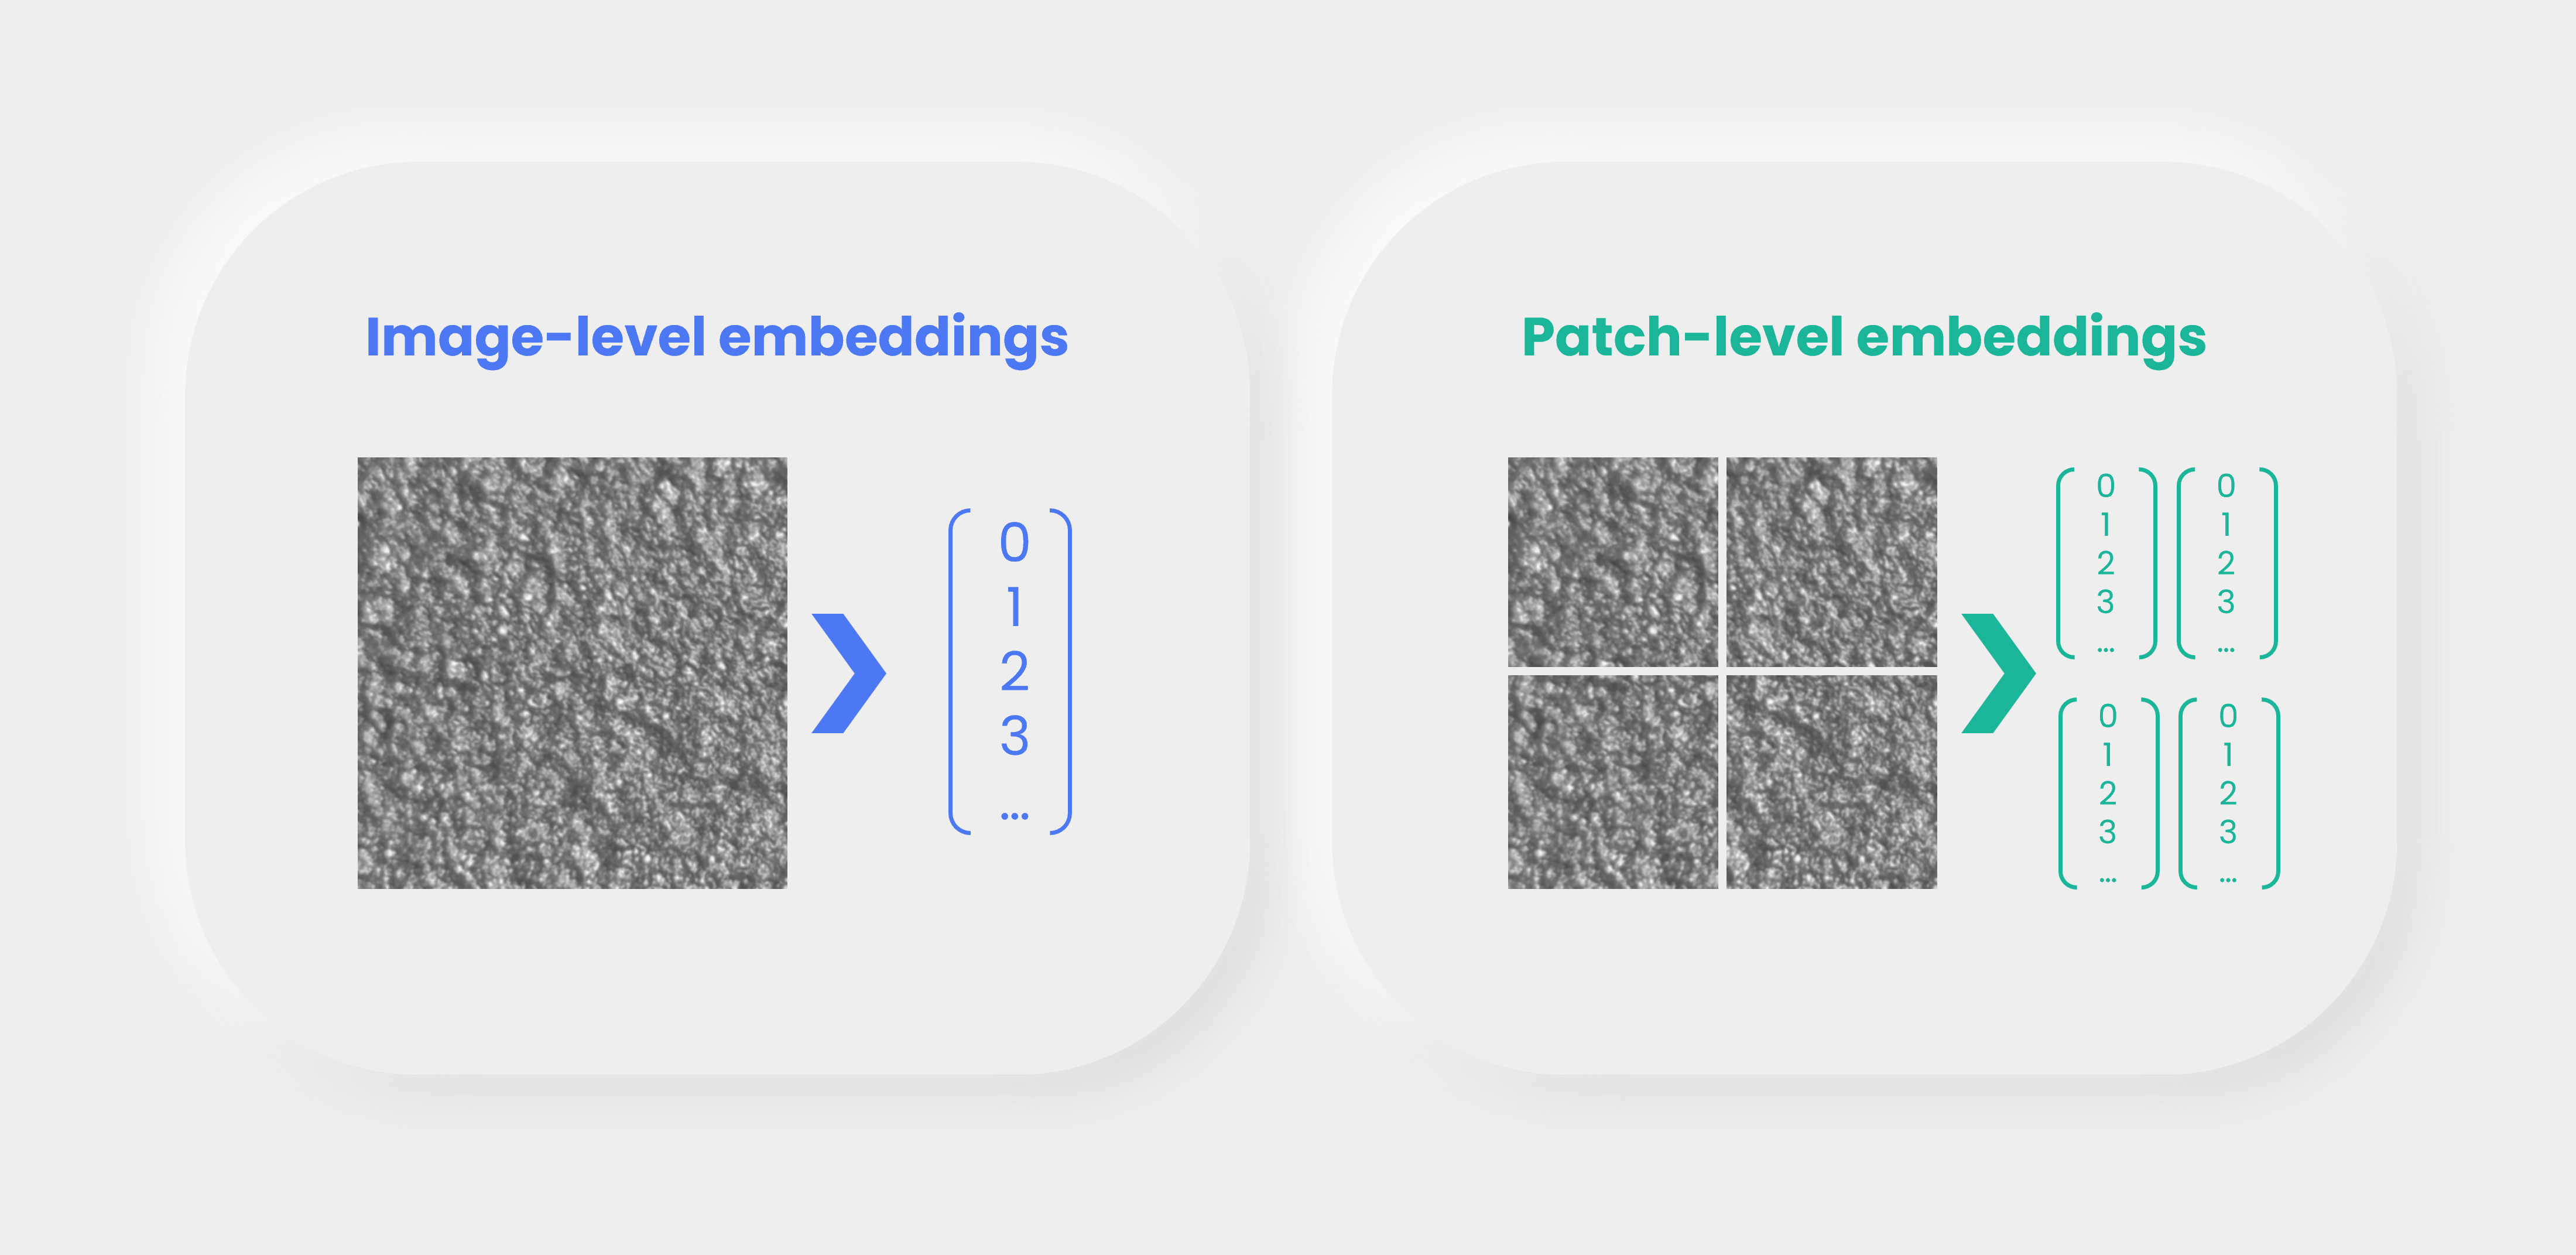

In [5]:
display(Image('../episodes/Fig/01_Image_vs_Patch_Embeddings.png', width=850))


*Figure 5: Image-level embeddings summarize the whole image. Patch-level embeddings preserve local information.*

Think of an embedding as a compressed description. A good embedding does not store every pixel. It stores the aspects of the image that the backbone has learned are useful: edges, repeated textures, shapes, transitions, and eventually larger visual patterns.

<div class='alert alert-info'>

:::{note}
**A handwriting analogy**: two people can write the word "steel" in wildly different handwriting -- different pixels, different stroke widths, different slant -- and you still read the same word. Somewhere between the raw ink strokes and the meaning "steel", your visual system threw away everything that doesn't matter (exact pixel positions) and kept only what does (the pattern of letters). A pretrained backbone's embedding is doing the same kind of lossy-but-useful compression for steel surface texture instead of handwriting.
:::
</div>

### 2.1 Image Embeddings vs Patch Embeddings

An image embedding compresses the whole image into one vector. That is convenient, but it can hide small local defects.

A patch embedding keeps a spatial grid of feature vectors. If a feature map has shape `[C, H, W]`, it contains `H x W` patch descriptors, each with `C` channels. PatchCore stores these local descriptors from normal images.


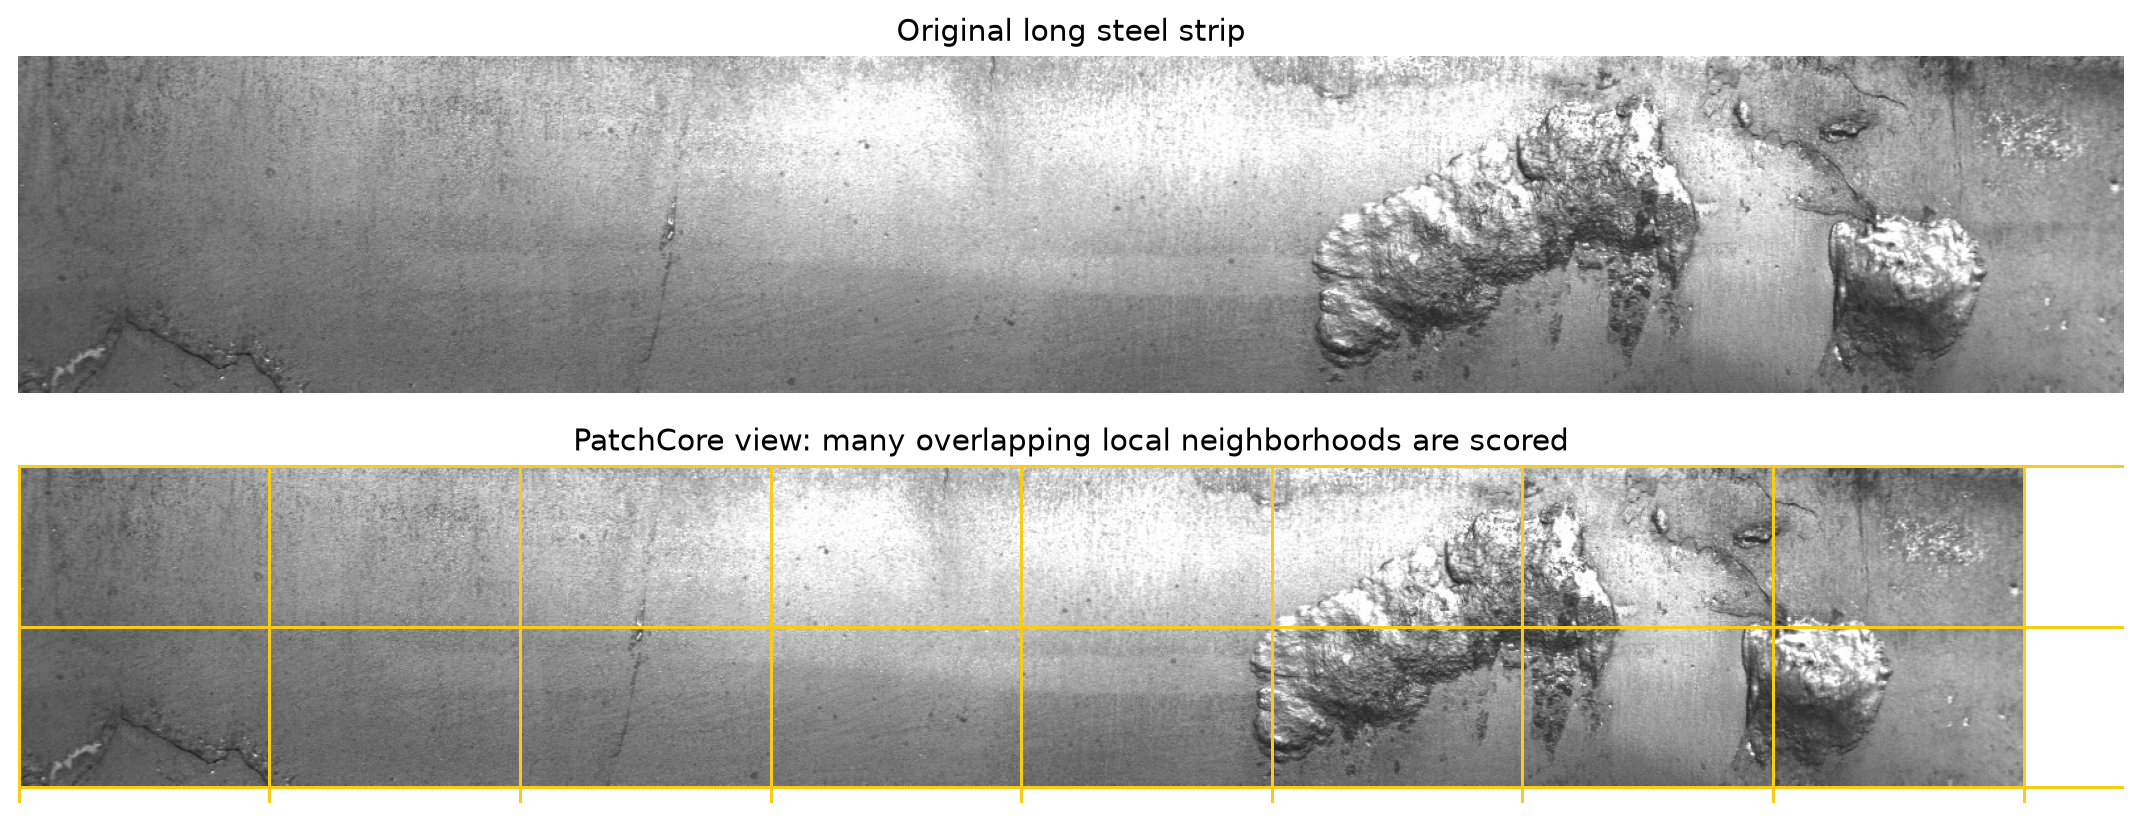

In [6]:
display(Image('../episodes/Fig/01_Steel_Patch_Grid.png', width=950))


*Figure 6: The long steel strip is treated as many local neighborhoods. PatchCore scores those local neighborhoods rather than relying only on one global image summary.*

In practice, these patches are not literally non-overlapping yellow boxes. CNN (convolutional neural network) and ViT (Vision Transformer) features have receptive fields and patch tokens that overlap in what they "see". The figure is a simplified teaching view: anomaly detection becomes easier when the model can ask many local questions instead of one global question.


In [14]:
batch_size, channels, height, width = 2, 512, 28, 28
feature_map = torch.randn(batch_size, channels, height, width)
patch_table = feature_map.permute(0, 2, 3, 1).reshape(-1, channels)

print('Feature map:', tuple(feature_map.shape))
print('Patch table:', tuple(patch_table.shape))
print('Patches per image:', height * width)


Feature map: (2, 512, 28, 28)
Patch table: (1568, 512)
Patches per image: 784


The tensor example above is the shape conversion behind the intuition:

- `[batch, channels, height, width]` is how CNN feature maps are usually stored in PyTorch.
- Each `(height, width)` location is one local feature descriptor.
- PatchCore reshapes the grid so each row is one patch vector.

If `height = 28` and `width = 28`, then one image contributes `784` local descriptors before any memory reduction. This is why memory-bank size becomes important quickly.

This is not just a shape trick on random numbers. You don't need to read every line below; just notice that the same `permute` + `reshape` step works on a **real** steel image passed through a **real** pretrained backbone.


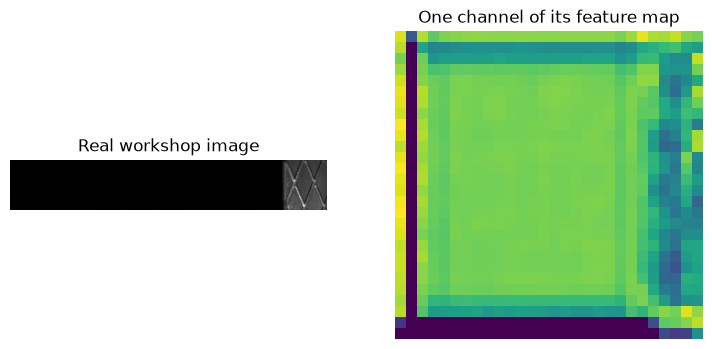

Real feature map: (1, 128, 28, 28)
Real patch table: (784, 128)


In [15]:
from PIL import Image as PILImage
import pandas as pd
import torchvision.transforms as T
import timm

theory_metadata = pd.read_csv(DATASET_ROOT / 'metadata.csv')
sample_row = theory_metadata[theory_metadata['workshop_split'] == 'train/normal'].iloc[0]
sample_image = PILImage.open(DATASET_ROOT / sample_row['relative_path']).convert('RGB')

preprocess = T.Compose([T.Resize((224, 224)), T.ToTensor()])
sample_tensor = preprocess(sample_image).unsqueeze(0)

real_backbone = timm.create_model('resnet18', features_only=True, pretrained=True, out_indices=(2,))
real_backbone.eval()
with torch.no_grad():
    real_feature_map = real_backbone(sample_tensor)[0]
real_patch_table = real_feature_map.permute(0, 2, 3, 1).reshape(-1, real_feature_map.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sample_image)
axes[0].set_title('Real workshop image')
axes[0].axis('off')
axes[1].imshow(real_feature_map[0, 0].numpy(), cmap='viridis')
axes[1].set_title('One channel of its feature map')
axes[1].axis('off')
plt.show()

print('Real feature map:', tuple(real_feature_map.shape))
print('Real patch table:', tuple(real_patch_table.shape))

A pretrained deep learning model turned the photo above into a `[1, C, H, W]` feature map, and the same reshape from the toy example turns it into a table of real patch vectors. The hands-on notebooks do exactly this, for every image in the dataset, at a larger scale.

## 3. One-class Reasoning in Feature Space

Imagine every normal patch as a point in feature space. Normal steel texture should occupy recurring regions in that space. A defect patch should often land far away from those normal regions.

This idea does not require a learned classifier. It only requires a useful feature space and a distance function.

<div class='alert alert-info'>

:::{note}
This is the same trick your immune system uses. T-cells are trained (via a selection process in the thymus) to recognize the body's own healthy cells as "self" and are discarded if they react to self. They are never shown a catalog of every virus and bacterium that might attack later; anything that doesn't match "self" closely enough is treated as suspicious by default. That is a one-class system: define normal well, then flag whatever fails to match it, without needing a name for the threat in advance. PatchCore's memory bank of normal patches plays the same role as the body's catalog of "self".
:::
</div>

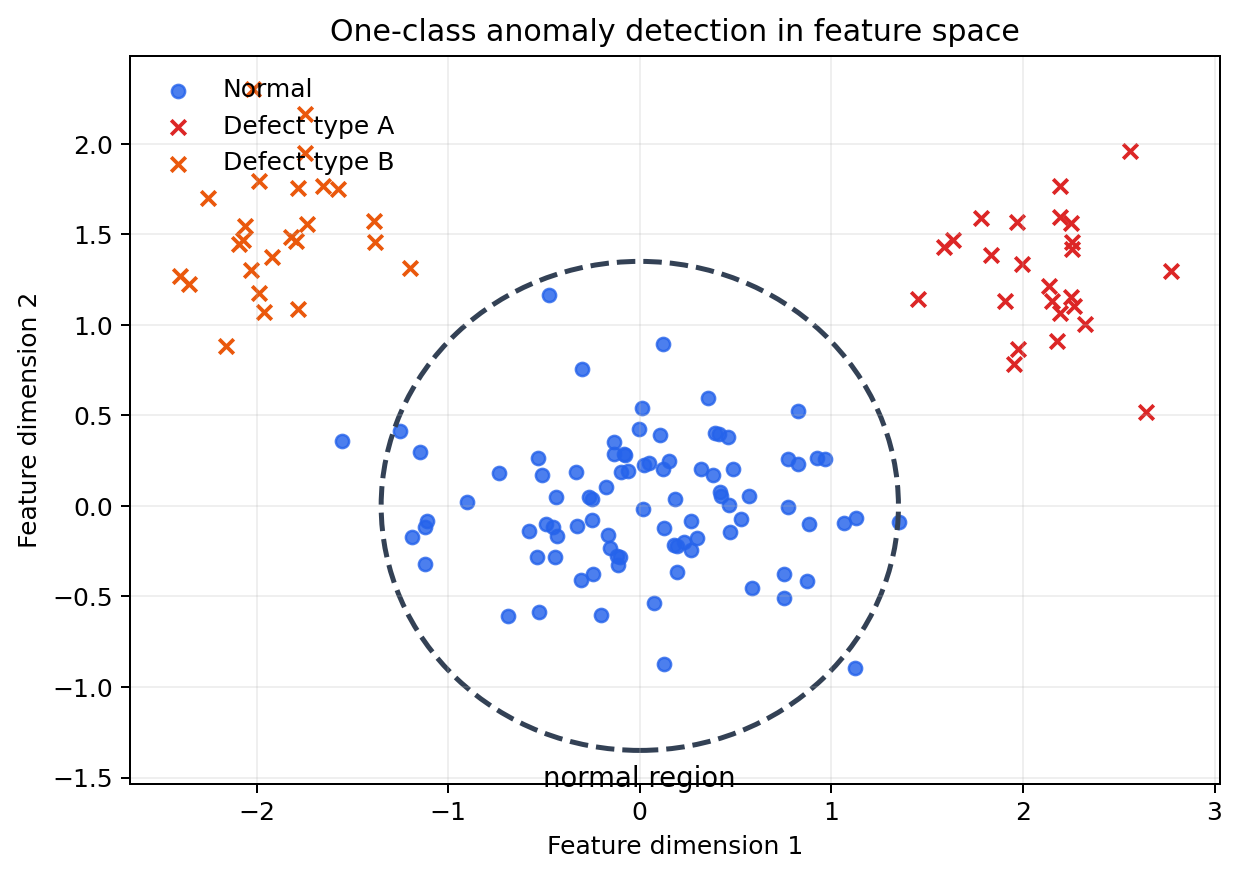

In [7]:
display(Image('../episodes/Fig/01_OneClass_FeatureSpace.png', width=650))


*Figure 7: A simplified feature-space picture. Normal examples form a region. Defect examples are suspicious when they fall far from that normal region.*

In real models this space is not two-dimensional. It may have hundreds or thousands of dimensions. We draw it in 2D because the idea is easier to see: "near normal" is reassuring, "far from normal" is suspicious.


### 3.1 PatchCore Anomaly Detection Algorithm: Nearest-neighbor Scoring

Section 3 just argued that "near normal" should mean "not anomalous" in feature space. PatchCore turns that idea into a concrete algorithm:

1. Save many normal patch vectors in a memory bank.
2. For a test patch, compute the distance -- the Euclidean (L2) distance between feature vectors -- from it to every vector in the memory bank, and keep the *smallest* one: the distance to its closest normal patch.
3. Use that smallest distance as the local, per-patch anomaly score.
4. Aggregate all of a test image's per-patch scores into one image-level anomaly score, usually by taking the **maximum** over patches: the single most suspicious patch determines the whole image's score, since a defect can be small and confined to one region.

The intuition is direct: if the closest normal patch is still far away, the test patch is suspicious. The toy demo below computes exactly this -- nearest-neighbor distance, then a max over patches -- end to end, on synthetic feature vectors.

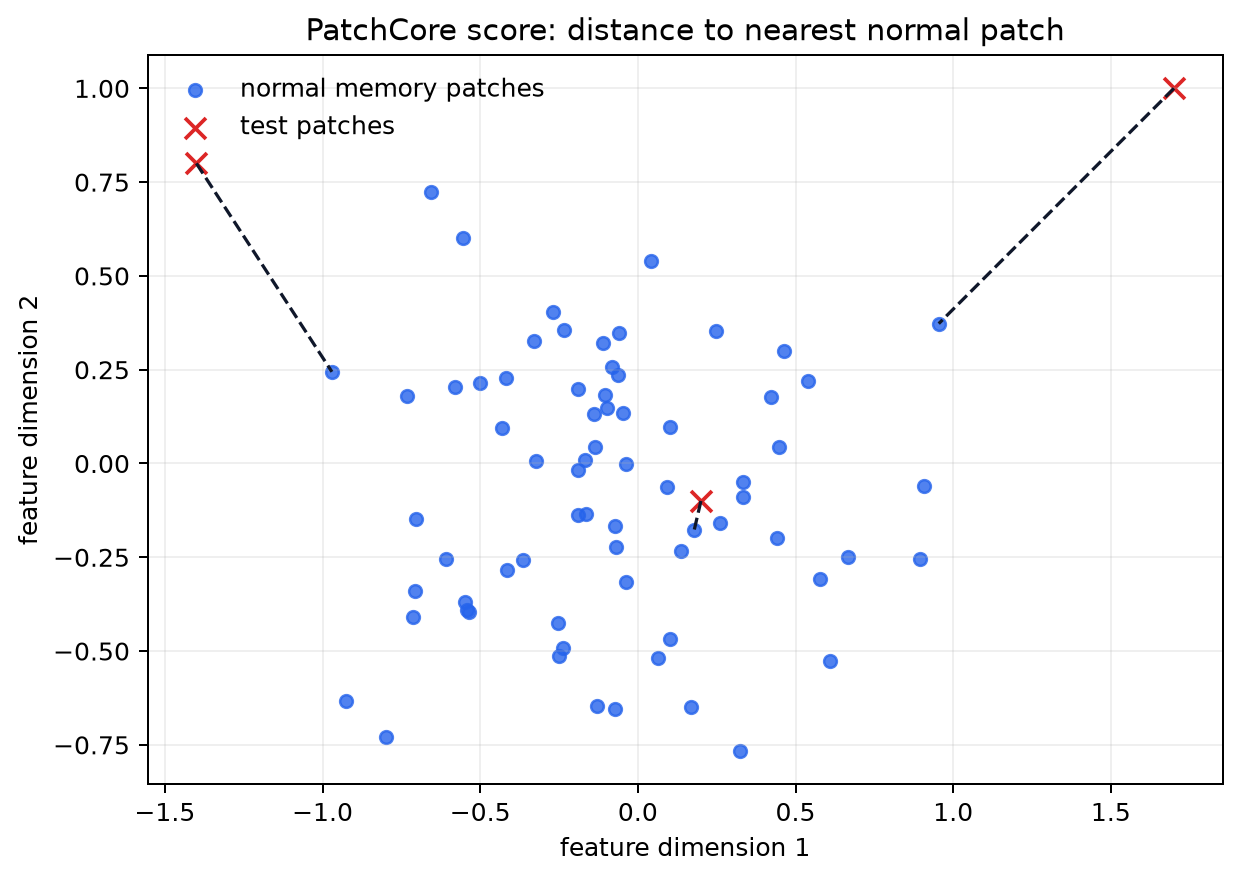

In [8]:
display(Image('../episodes/Fig/01_Nearest_Neighbor_Scoring.png', width=700))


*Figure 8: Every test patch asks for its closest normal patch. The longer the dashed line, the more unusual that test patch is.*

This is not a probability from a softmax classifier. It is a distance-based score. That distinction matters: the model is not saying "this is defect type 3 with 91% probability". It is saying "this local pattern is far from the normal patterns I stored".


In [18]:
normal_memory = torch.randn(250, 64) * 0.5

num_toy_images = 40
patches_per_image = 30
normal_images = torch.randn(num_toy_images, patches_per_image, 64) * 0.5
abnormal_images = torch.randn(num_toy_images, patches_per_image, 64) * 0.5 + 1.4

def image_score(test_patches, memory_bank):
    distances = torch.cdist(test_patches, memory_bank)
    return distances.min(dim=1).values.max()

normal_scores = torch.stack([image_score(patches, normal_memory) for patches in normal_images])
abnormal_scores = torch.stack([image_score(patches, normal_memory) for patches in abnormal_images])

print(f'Mean normal image score:   {normal_scores.mean():.3f}')
print(f'Mean abnormal image score: {abnormal_scores.mean():.3f}')


Mean normal image score:   5.045
Mean abnormal image score: 12.109


The toy example is deliberately simple: forty "abnormal" toy images are built from patches shifted away from the normal memory. The same principle applies in a real backbone feature space, but the shift is not manually created. It comes from visual differences in texture, edges, contrast, and local structure.

Each image's score uses its single most suspicious local patch (the maximum over per-patch nearest-neighbor distances). This is useful for industrial defects because a defect may occupy only a small part of a large image. We will reuse `normal_scores` and `abnormal_scores` in Section 5.2 to compute a real AUROC number.


## 4. PatchCore Step by Step

**PatchCore** is a practical engineering recipe around nearest-neighbor scoring:
- choose a pretrained backbone;
- select intermediate layers;
- extract normal patch features;
- reduce the memory bank with coreset sampling;
- compare test patches to the memory bank;
- upsample patch scores into an anomaly heatmap.

Its strength is that it often works well without training a task-specific deep network. But in some cases, fine-tuning the backbone on normal images can improve performance.

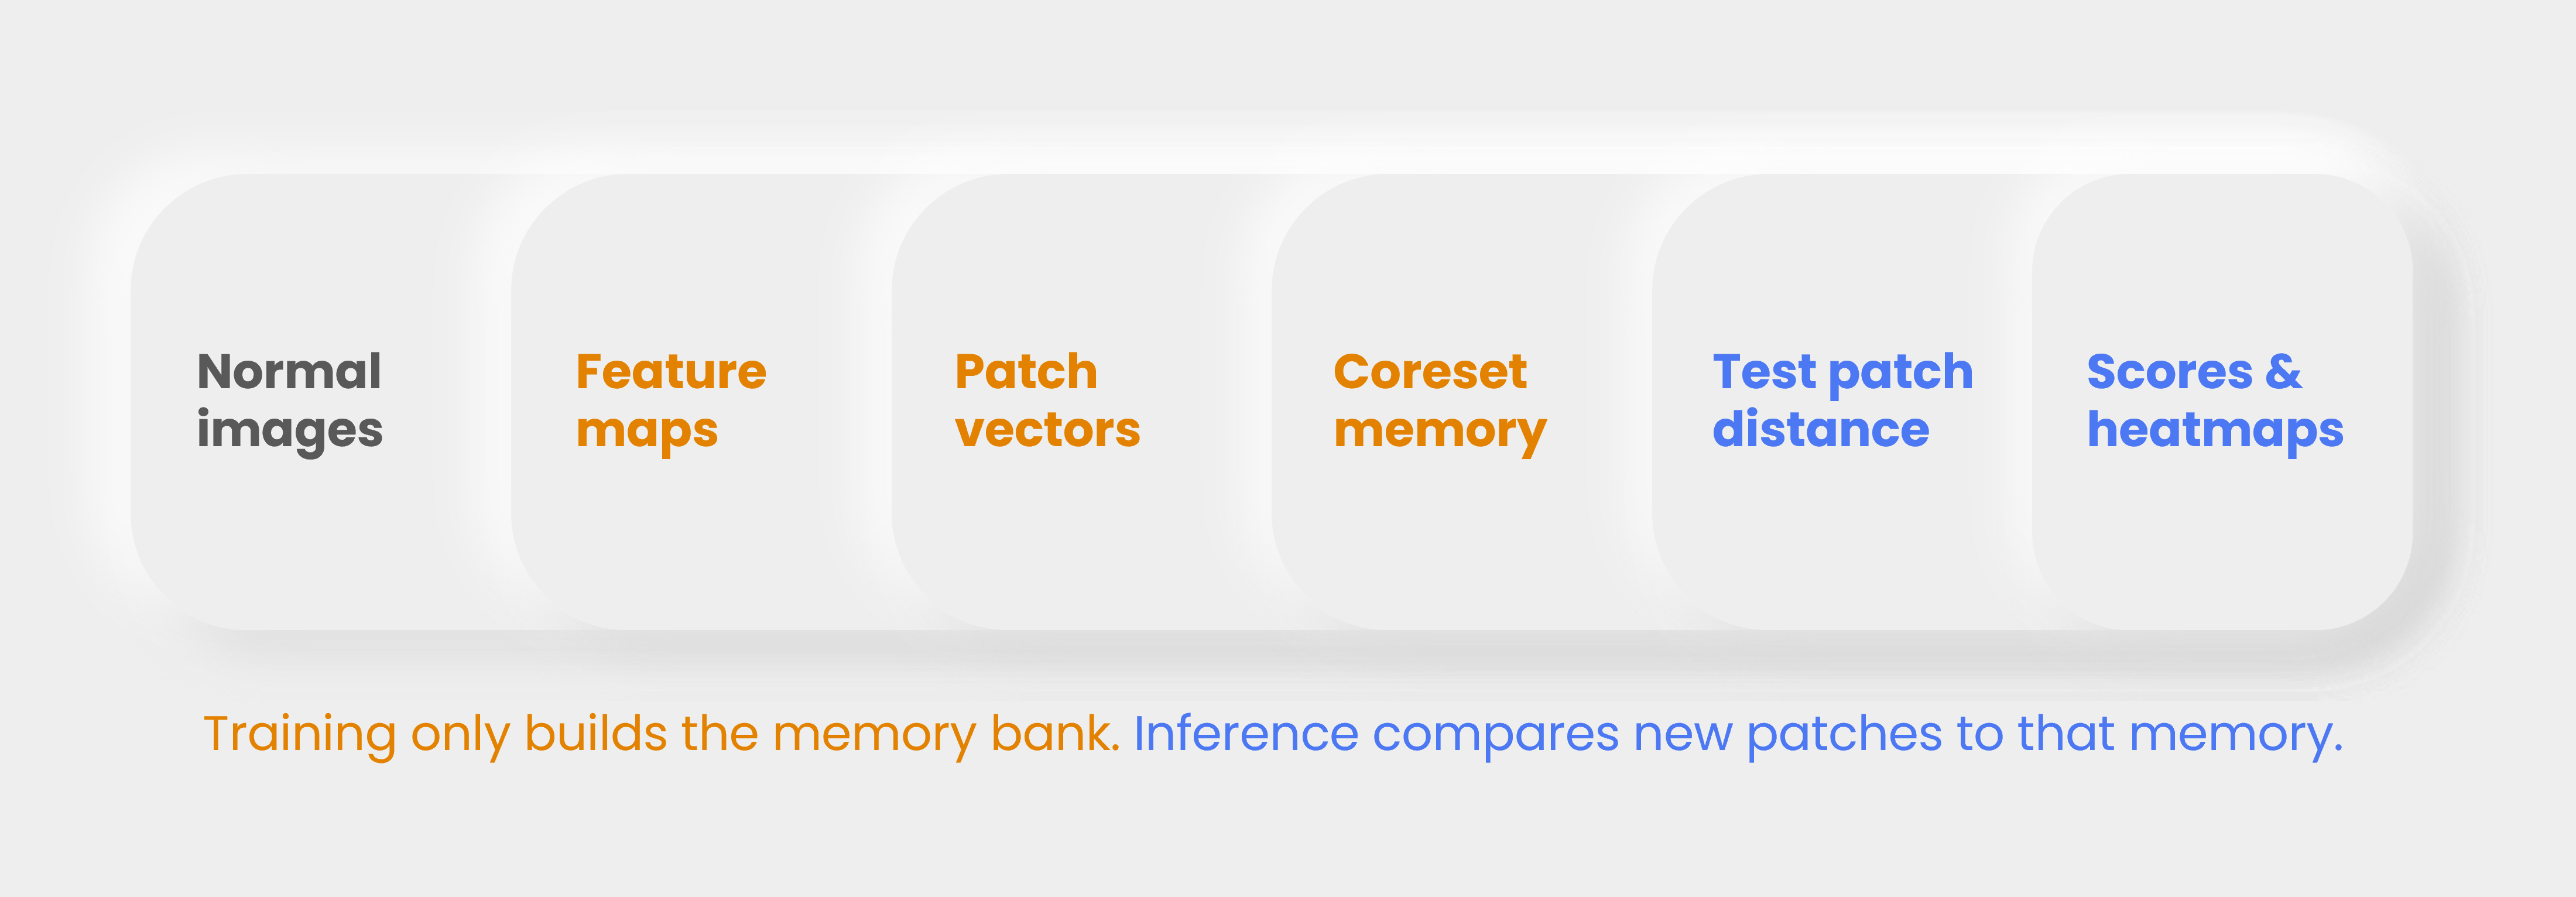

In [9]:
display(Image('../episodes/Fig/01_PatchCore_Detailed_Pipeline.png', width=950))


*Figure 9: PatchCore has a training phase and an inference phase. Training creates the normal memory. Inference compares new image patches to that memory.*

<div class='alert alert-info'>

:::{note}
The word "training" can be misleading here. PatchCore is not doing the same kind of gradient-based training as a CNN classifier. It does not spend epochs updating millions of weights for a new classification head. Most of the work is feature extraction and memory-bank construction.
:::
</div>

### 4.1 The Memory Bank

The memory bank is the set of normal patch descriptors. It is not a neural network layer and it is not learned by backpropagation. It is closer to a lookup table of normal examples in feature space.

Larger memory banks can represent normal variation better, but they also increase runtime and memory usage. This is why PatchCore includes **coreset sampling**.


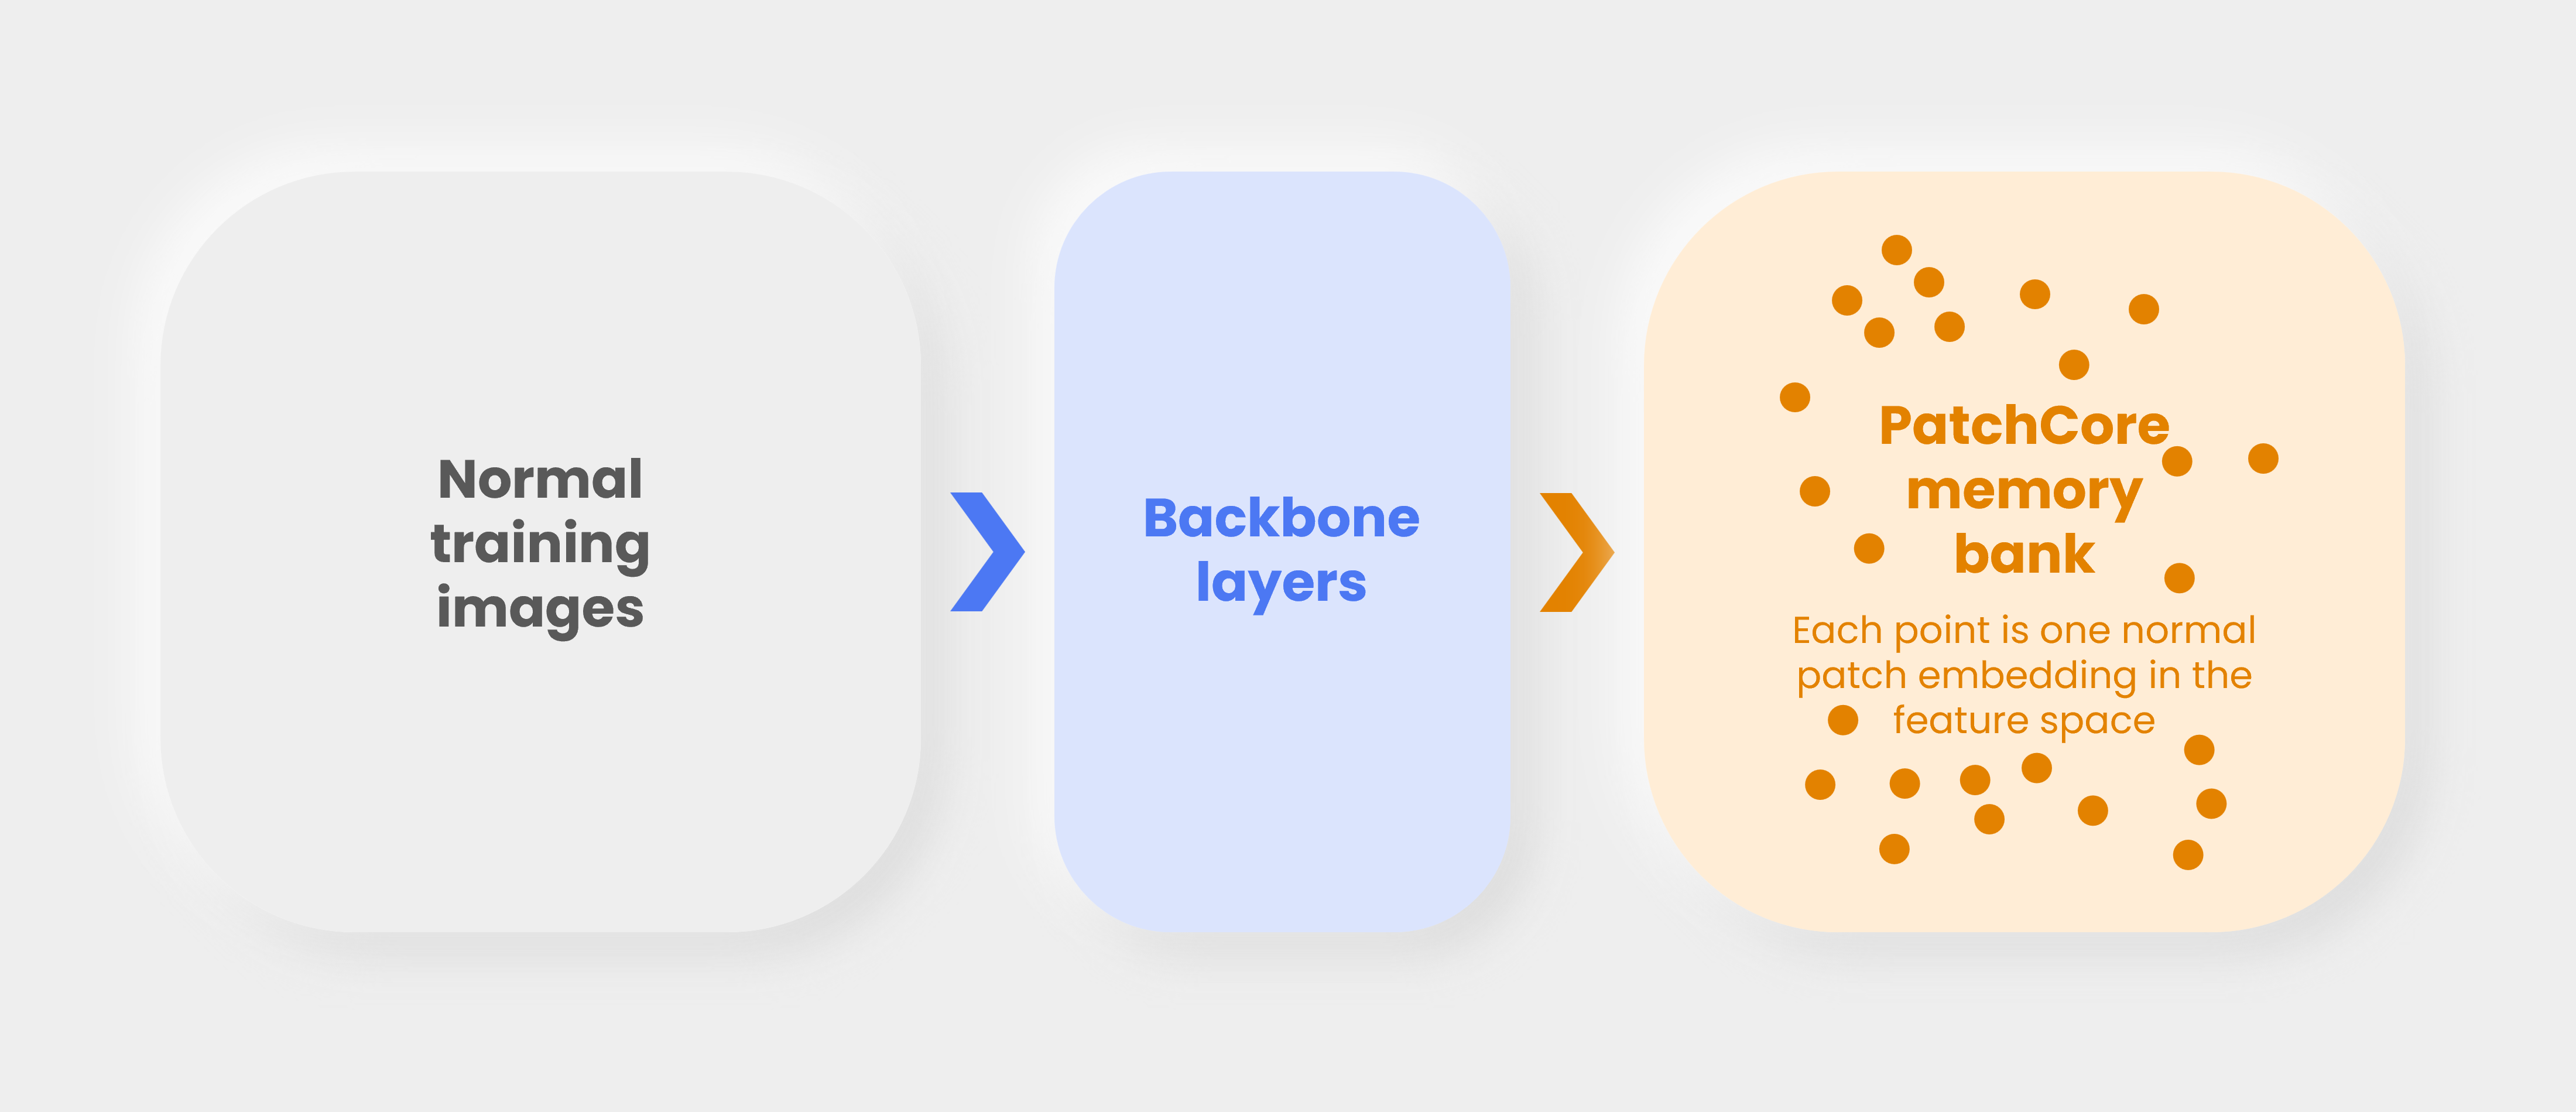

In [10]:
display(Image('../episodes/Fig/01_PatchCore_MemoryBank.png', width=850))


*Figure 10: The memory bank stores local normal patch embeddings. At test time, every new patch is compared with this bank.*

A useful analogy is a library of normal texture snippets. If a test snippet resembles something in the library, it is probably normal. If it has no good match, it deserves attention.


### 4.2 Coreset Sampling

Coreset sampling keeps a representative subset of normal patch vectors. The goal is to cover the same feature-space territory with fewer points.

In the hands-on notebook, `coreset_sampling_ratio` is one of the main knobs:

- higher ratio: more memory, potentially better coverage, slower inference;
- lower ratio: faster and lighter, but may miss normal variation.


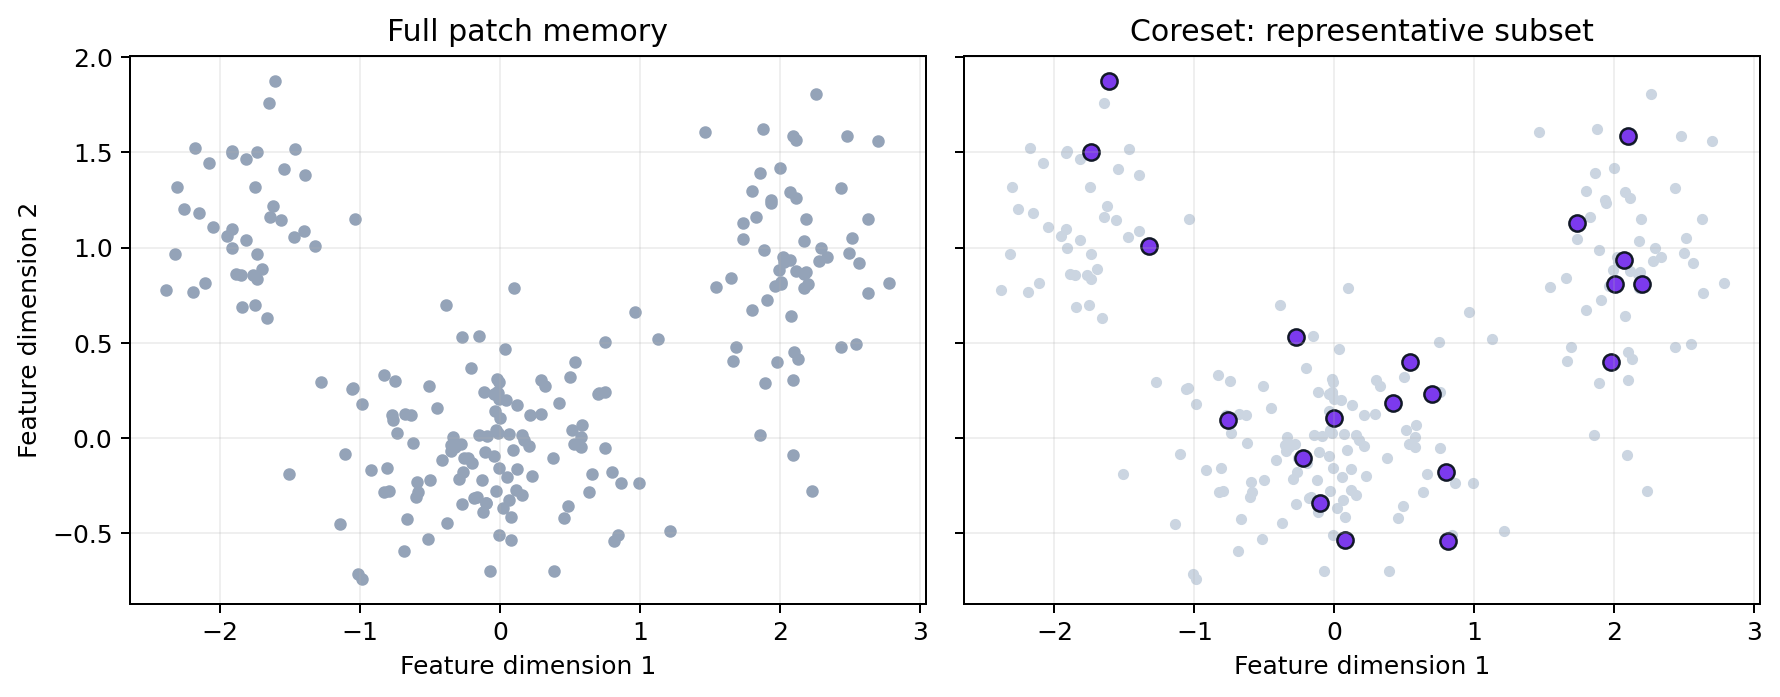

In [11]:
display(Image('../episodes/Fig/01_Coreset_Sampling.png', width=850))


*Figure 11: Coreset sampling removes redundancy while trying to keep coverage of the normal feature distribution.*

If many normal patches are almost identical, keeping all of them is wasteful. Coreset sampling tries to keep the patches that best represent the spread of normality. This is one reason PatchCore can be practical even when each image contributes many patch descriptors.


A concrete look at coreset sampling

Coreset sampling is not a vague "keep some points" idea. Anomalib's PatchCore uses a **greedy farthest-point** algorithm (also called k-center greedy, or minimax facility location):

1. Start with all normal patch points, and an empty selected set, a placeholder for the coreset.
2. Pick one starting point at random and add it to the selected set.
3. Repeat until the selected set reaches the target size:
   - for every point, compute its distance to the *nearest* point already selected;
   - pick the point with the **largest** such distance — the point currently worst represented;
   - add that point to the selected set.

This is repeated until the coreset reaches the desired size. The result is a set of points that are spread out in feature space, capturing the diversity of normal patches without redundancy.

You don't need to trace every line of the code below. Focus on the plot: the coreset should spread out and pick boundary/representative points rather than piling up inside the dense clusters.


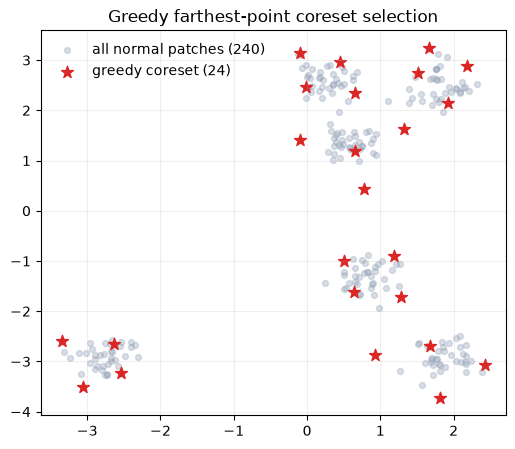

In [22]:
rng = np.random.default_rng(0)
cluster_centers = rng.uniform(-3, 3, size=(6, 2))
normal_patches_2d = torch.tensor(
    np.concatenate([rng.normal(loc=center, scale=0.25, size=(40, 2)) for center in cluster_centers]),
    dtype=torch.float32,
)  # 240 redundant "normal patch" points in 6 clusters

def greedy_coreset(points, k, seed=0):
    n = points.shape[0]
    generator = torch.Generator().manual_seed(seed)
    selected = [torch.randint(n, (1,), generator=generator).item()]
    min_dist = torch.cdist(points, points[selected]).squeeze(1)
    for _ in range(k - 1):
        idx = torch.argmax(min_dist).item()
        selected.append(idx)
        min_dist = torch.minimum(min_dist, torch.cdist(points, points[idx:idx + 1]).squeeze(1))
    return selected

coreset_idx = greedy_coreset(normal_patches_2d, k=24)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(normal_patches_2d[:, 0], normal_patches_2d[:, 1], s=18, alpha=0.35, color='#94a3b8', label='all normal patches (240)')
ax.scatter(normal_patches_2d[coreset_idx, 0], normal_patches_2d[coreset_idx, 1], s=80, color='#dc2626', marker='*', label='greedy coreset (24)')
ax.set_title('Greedy farthest-point coreset selection')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()


This is not a simplified analogy — it is essentially the same algorithm `anomalib`'s `KCenterGreedy` sampler runs internally on real patch embeddings. At production scale, PatchCore first applies a random projection to shrink the embedding dimensionality before running this loop, purely for speed; the selection logic itself is identical to what you just ran.

Notice how the coreset (red stars) avoids clustering inside the dense blobs. It prefers points that are still far from everything already chosen, which is exactly what "keep coverage of the normal distribution while dropping redundancy" means in practice.


## 5. Heatmaps, Image Scores, and Thresholds

A PatchCore heatmap is a spatial view of patch distances. Bright regions are patches that look far from the normal memory bank.

The image-level score is usually derived from the strongest suspicious region. A threshold then turns the continuous score into a decision:
- below threshold: accept as normal;
- above threshold: flag as anomalous.

Thresholds are operational choices. A steel mill may prefer more false alarms if missed defects are expensive.

<div class='alert alert-info'>

:::{note}
A smoke detector faces the identical tradeoff. Set the sensitivity too low and it stays silent while the kitchen fills with smoke from burning oil. Set it too high and it screams every time someone browns butter. Nobody asks "what is the *correct* sensitivity for a smoke detector" in the abstract. The right answer depends on how costly a missed fire is versus how annoying a false alarm is. A PatchCore threshold is the same knob, tuned for a specific production line instead of a specific kitchen.
:::
</div>

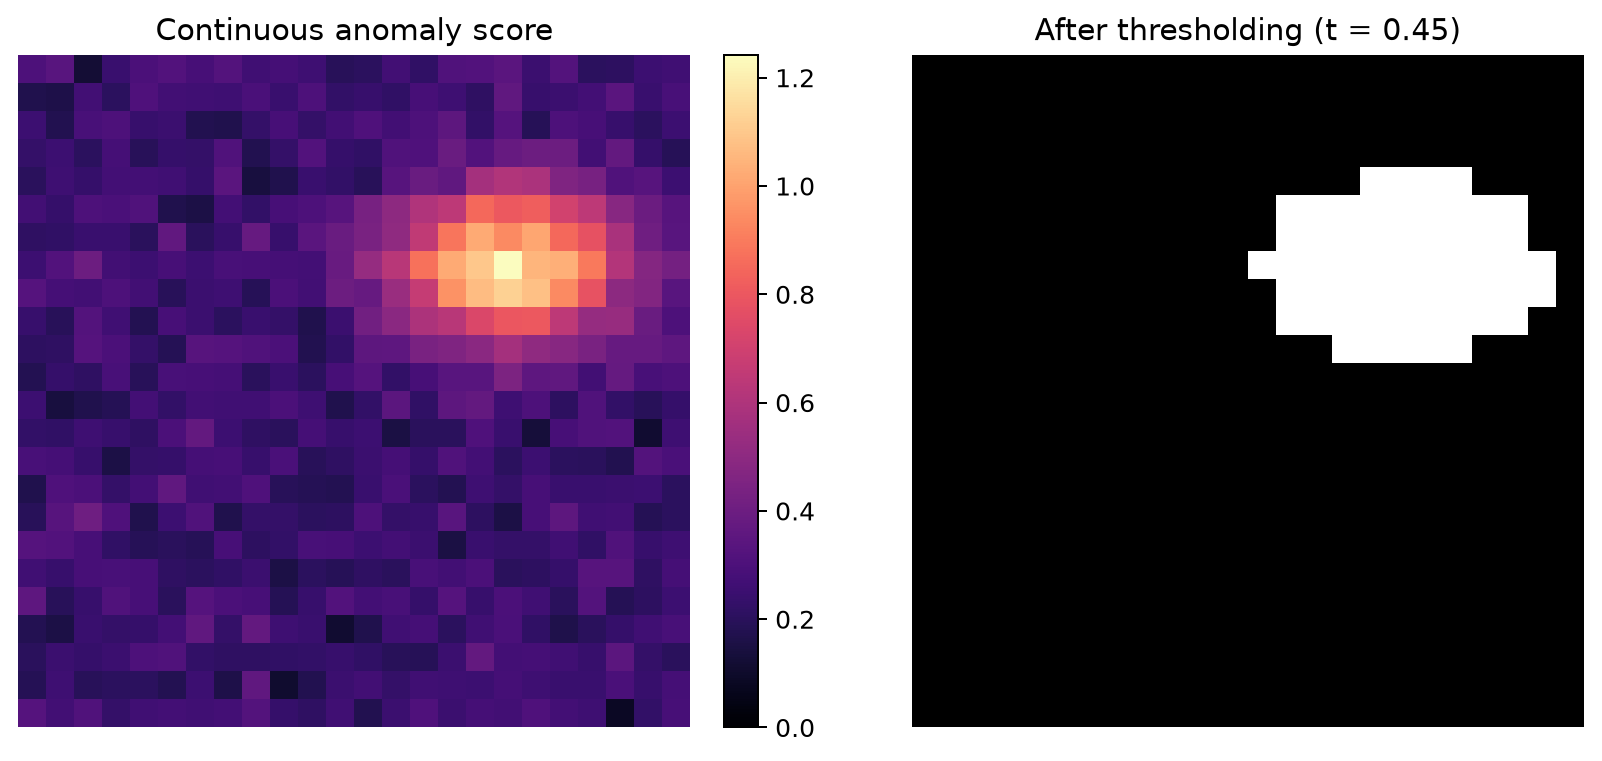

In [12]:
display(Image('../episodes/Fig/01_AnomalyMap_Threshold.png', width=850))


*Figure 12: Local patch scores become a heatmap. A threshold turns continuous scores into a binary decision.*

Heatmaps are often as important as the final number. If the model flags an image as anomalous but the heatmap highlights an irrelevant border artifact, the model may be learning the wrong cue.


From a coarse score grid to a smooth heatmap

The heatmap in Figure 12 does not appear out of thin air. PatchCore scores a coarse grid of patches (for example `28x28` for a `224x224` image), then has to turn that coarse grid into a full-resolution heatmap. Anomalib does this in two steps:

1. **Upsample** the coarse grid to image resolution with nearest-neighbor interpolation — each coarse cell is simply repeated into a block of pixels.
2. **Smooth** the result with a Gaussian blur, which turns the blocky upsampled grid into the soft heatmap you actually see.


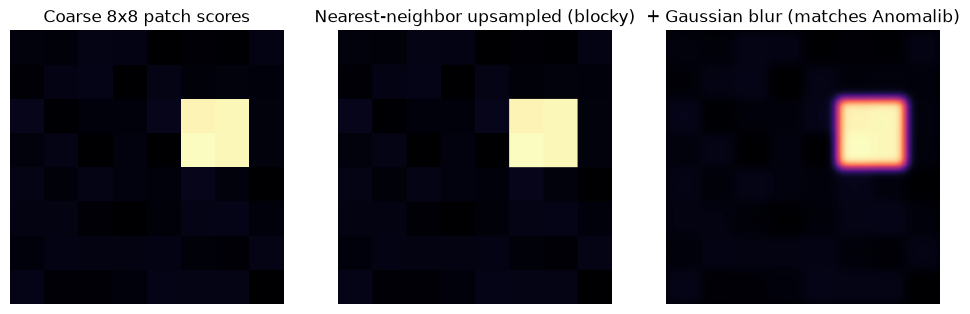

In [24]:
import torch.nn.functional as F

coarse_scores = torch.rand(1, 1, 8, 8) * 0.15
coarse_scores[0, 0, 2:4, 5:7] += 3.0  # simulated local defect region

nearest_upsampled = F.interpolate(coarse_scores, size=(224, 224), mode='nearest')

def gaussian_blur(x, sigma=4):
    kernel_size = 2 * int(4 * sigma + 0.5) + 1
    coords = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
    kernel_1d = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    kernel_1d /= kernel_1d.sum()
    kernel_2d = (kernel_1d[:, None] * kernel_1d[None, :]).view(1, 1, kernel_size, kernel_size)
    return F.conv2d(x, kernel_2d, padding=kernel_size // 2)

smooth_heatmap = gaussian_blur(nearest_upsampled, sigma=4)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].imshow(coarse_scores.squeeze(), cmap='magma')
axes[0].set_title('Coarse 8x8 patch scores')
axes[1].imshow(nearest_upsampled.squeeze(), cmap='magma')
axes[1].set_title('Nearest-neighbor upsampled (blocky)')
axes[2].imshow(smooth_heatmap.squeeze(), cmap='magma')
axes[2].set_title('+ Gaussian blur (matches Anomalib)')
for ax in axes:
    ax.axis('off')
plt.show()


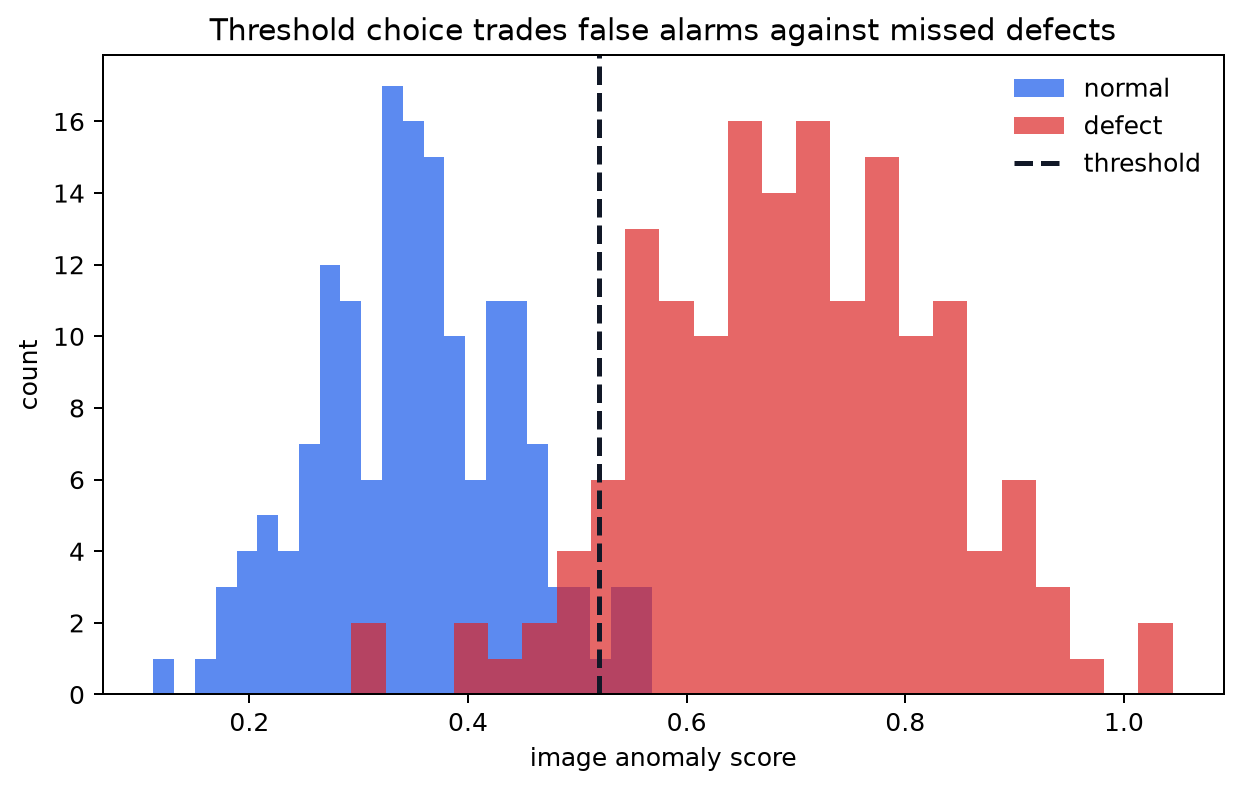

In [13]:
display(Image('../episodes/Fig/01_Threshold_Metrics.png', width=700))


*Figure 13: Score distributions and thresholding. Moving the threshold changes the balance between false alarms and missed defects.*

There is no universally correct threshold. A threshold is a business and engineering choice. In safety-critical inspection, missing a defect may be much worse than sending extra images to manual review. In a high-throughput line, too many false alarms can also be costly.


### 5.1 Metrics for This Workshop

We focus on image-level evaluation:

- AUROC: how well scores rank defects above normals across thresholds;
- F1: a threshold-dependent balance of precision and recall;
- qualitative heatmaps: do highlighted regions make visual sense?

Pixel-level metrics are useful when masks are available, but they add annotation conversion work. We intentionally keep them out of this module.


### 5.2 How to interpret AUROC and F1

AUROC asks: if we randomly pick one normal image and one defect image, how often does the defect image receive a higher anomaly score? It is threshold-independent and useful for comparing score quality.

F1 depends on a chosen threshold. It combines precision and recall:

- precision asks: when the model raises an alarm, how often is it correct?
- recall asks: of all actual defects, how many did the model catch?

In the hands-on section, do not only chase one metric. Also inspect heatmaps and failure cases.


`normal_scores` and `abnormal_scores` from Section 3.1 are exactly what AUROC measures. We don't need a real dataset to make the metric concrete: label those toy image scores (0 = normal, 1 = abnormal) and compute a real AUROC number and ROC curve right now.


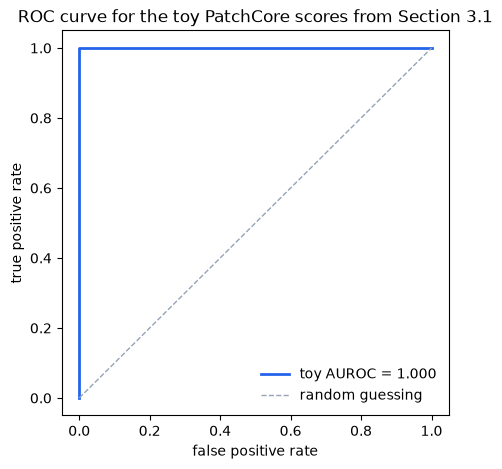

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve

toy_scores = torch.cat([normal_scores, abnormal_scores]).numpy()
toy_labels = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(abnormal_scores))])

toy_auroc = roc_auc_score(toy_labels, toy_scores)
fpr, tpr, _ = roc_curve(toy_labels, toy_scores)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='#2563eb', lw=2, label=f'toy AUROC = {toy_auroc:.3f}')
ax.plot([0, 1], [0, 1], color='#94a3b8', lw=1, ls='--', label='random guessing')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC curve for the toy PatchCore scores from Section 3.1')
ax.legend(frameon=False)
plt.show()


This toy AUROC is very high because the abnormal patches were hand-shifted far away from the normal memory. In the hands-on notebook, the same computation runs on real steel images, and the separation between normal and defect scores is rarely this clean — that gap between "toy AUROC" and "real AUROC" is itself a useful discussion point.

Think of AUROC as grading your model on how perfectly it orders your predictions. If your positive examples always score higher than your negative examples, your AUROC is perfect (1.0). If your model is no better than random guessing, your AUROC is 0.5. If your model is worse than random, your AUROC is below 0.5.

However, even if the AUROC is perfect, the F1 score could be low. This happens if your chosen classification threshold doesn't cleanly separate the two groups, resulting in poor Precision or Recall. In practice, you will often tune the threshold to balance these metrics according to your operational needs.

## 6. Backbone Choice

PatchCore is not tied to one architecture. The backbone defines the feature geometry.

In this workshop:

- `resnet18` is the fast smoke-test option;
- `wide_resnet50_2` is the recommended CNN baseline; CNNs are fast and memory-efficient, and have been the standard for industrial inspection for years, at least until the "transformer revolution". They are still a strong choice for many defect types.
- `vit_small_patch14_dinov2.lvd142m` tests transformer-style DINOv2 features. The transformer architecture is more computationally expensive, but it can capture larger context and may produce better embeddings for certain defect types.

The best choice depends on accuracy, runtime, memory, and heatmap usefulness.


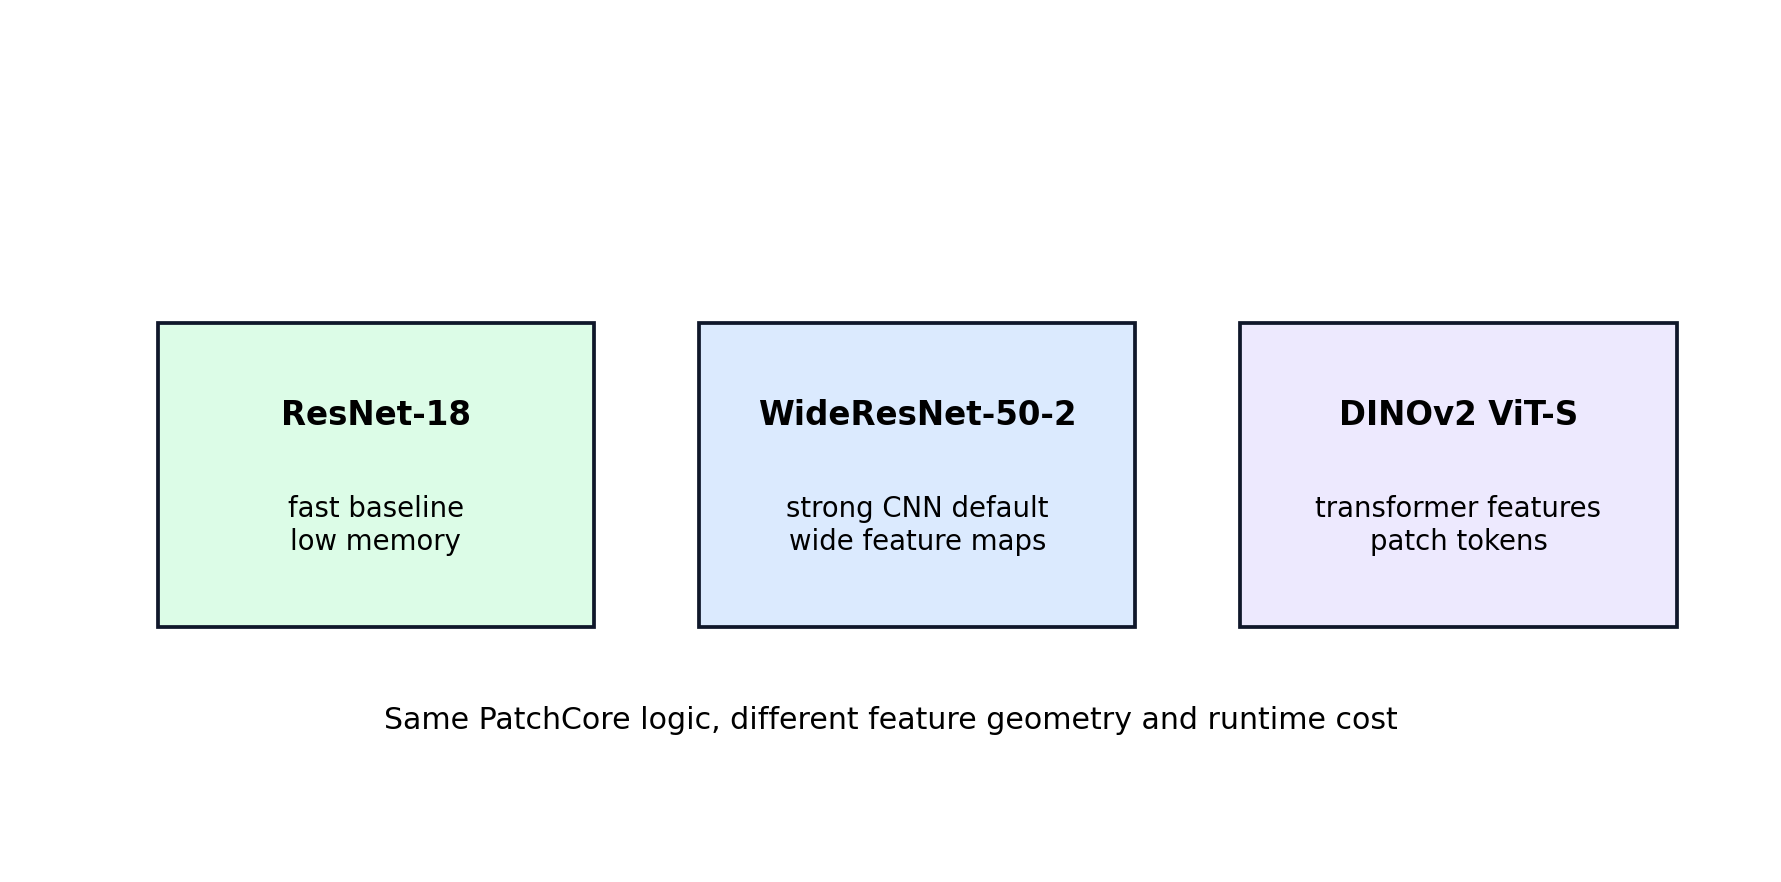

In [14]:
display(Image('../episodes/Fig/01_CNN_vs_ViT_Backbones.png', width=850))


*Figure 14: The same PatchCore method can use different pretrained backbones. The backbone changes what "similar" means in feature space.*

Practical intuition:

- `resnet18` is useful when you want quick feedback. It has fewer parameters and usually runs faster.
- `wide_resnet50_2` is often a strong PatchCore baseline because the wider feature channels provide rich local descriptors.
- `vit_small_patch14_dinov2.lvd142m` uses transformer-style features. It may capture different structure, but it can be slower and heavier.

The the best answer is empirical.


In [28]:
try:
    import timm
    for backbone in ['resnet18', 'wide_resnet50_2', 'vit_small_patch14_dinov2.lvd142m']:
        model = timm.create_model(backbone, features_only=True, pretrained=False)
        print(backbone, 'feature layers:', model.feature_info.module_name())
except Exception as exc:
    print('Could not inspect timm feature layers:', exc)


resnet18 feature layers: ['act1', 'layer1', 'layer2', 'layer3', 'layer4']


wide_resnet50_2 feature layers: ['act1', 'layer1', 'layer2', 'layer3', 'layer4']


vit_small_patch14_dinov2.lvd142m feature layers: ['blocks.9', 'blocks.10', 'blocks.11']


<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>💡 Looking ahead — Episode 3</strong>
<p>This section uses <code>resnet18</code>, <code>wide_resnet50_2</code>, and a ViT backbone as fixed feature extractors — the same concept introduced in Section 1.3. The internal architecture of these models (why ResNet's skip connections matter, how ViT processes image patches) and the practical question of when to freeze vs fine-tune are covered in depth in <a href="../3-TL-VGG-ResNet-ViT-lesson/">Episode 3 (Transfer Learning — VGG, ResNet, ViT)</a>.</p>
</div>

## 7. Practical Failure Modes

Of course, not all methods are perfect. Common anomaly detection failure modes:

- the normal training set is too narrow, so normal variation is flagged as anomalous;
- the backbone is too semantic and ignores small texture defects;
- the image resize distorts important geometry;
- the threshold is selected on too few examples;
- heatmaps highlight edges, shadows, or acquisition artifacts instead of defects.

The hands-on notebooks are designed to expose these tradeoffs rather than hide them.


### 7.1 What good troubleshooting looks like

When PatchCore behaves badly, ask concrete questions:

- Are the training images truly normal?
- Are the test images preprocessed the same way as training images?
- Is the heatmap pointing to the defect, or to a border/crop/lighting cue?
- Does the backbone preserve texture detail at the selected layers?
- Is the memory bank too small after coreset sampling?

These questions are more useful than simply trying random hyperparameters. They connect the result back to the method's assumptions.


<div class='alert alert-success'>

:::{exercise}
- In this episode:
    - Re-run the Section 1.3 classifier experiment holding out a *different* defect class (for example `defect_1` or `defect_2` instead of `defect_4`) -- is the catch-rate gap always this large, or does it depend on how visually distinct the held-out class is from the others?
    - Re-run the coreset demo in Section 4.2 with a smaller `k` (for example 8 instead of 24) and see how coverage of the clusters degrades.
    - In the hands-on Anomalib notebook, compare `coreset_sampling_ratio` and `num_neighbors` across backbones and connect the result back to what you saw in the toy demo.
    - Read about **PaDiM** and **SPADE**, two other feature-embedding-based anomaly detection methods that predate PatchCore, to see what problem PatchCore's coreset sampling and patch-level scoring were specifically designed to solve.
    - Try swapping the toy backbone in Section 2.1 for `wide_resnet50_2` or a ViT and compare the real feature map shapes.
- In the hands-on notebooks:
    - First visualize feature embeddings with PCA and t-SNE;
    - Then use Anomalib to train and evaluate PatchCore end to end on the prepared Severstal subset.
:::
</div>

<div class='alert alert-info'>

:::{keypoints}
If one phrase should stay with you, it is this: **PatchCore is a nearest-neighbor method over pretrained local image features.** - The more important habit to leave with, though, is the one built in Section 1: before reaching for an unfamiliar method, build the boring baseline first and let its failure mode tell you what you actually need.
- The path through this notebook was deliberately not a straight line to PatchCore:
    - Section 1 built increasingly realistic "obvious" solutions -- a tiny MLP, then a pretrained-backbone classifier -- on real steel images, and showed the latter structurally fails on a defect type it never trained on. That is an **open-set recognition** problem, not a "use a bigger model" problem.
    - Sections 2-6 built a different answer from the ground up: turn images into feature vectors, then ask "have we seen something like this in normal production?" instead of "which known class is this?"
- PatchCore is a strong industrial anomaly detection baseline because it combines:
    - pretrained visual representations;
    - local patch-level comparison;
    - a normal memory bank, reduced by greedy coreset sampling;
    - nearest-neighbor anomaly scores, upsampled and blurred into a heatmap;
    - a threshold-dependent decision (F1) plus a threshold-free ranking measure (AUROC).
:::
</div>

<div class='alert alert-info'>

:::{seealso}
- Roth et al., ["Towards Total Recall in Industrial Anomaly Detection"](https://arxiv.org/abs/2106.08265), CVPR 2022 -- the PatchCore paper.
- Defard et al., ["PaDiM: a Patch Distribution Modeling Framework for Anomaly Detection and Localization"](https://arxiv.org/abs/2011.08785), 2020 -- an earlier patch-based method PatchCore builds on conceptually.
- Cohen and Hoshen, ["Sub-Image Anomaly Detection with Deep Pyramid Correspondences"](https://arxiv.org/abs/2005.02357) (SPADE), 2020.
- Scheirer et al., ["Toward Open Set Recognition"](https://ieeexplore.ieee.org/document/6365193), TPAMI 2013 -- the formal framing behind Section 1.3's "held-out class" experiment.
- [Anomalib 2.5 documentation](https://anomalib.readthedocs.io/) for `Folder`, `Patchcore`, and `Engine`.
- [Timm model library](https://github.com/huggingface/pytorch-image-models) for PyTorch backbones.
:::
</div>